# 08. MÔ HÌNH SỐ 4: SETAR / TAR — USD/VND

Triển khai mô hình ngưỡng tự kích hoạt trên **log_return**, theo danh sách phương pháp của nhóm. SETAR là một trường hợp của TAR: biến ngưỡng chính là return quá khứ của chuỗi.

Mục tiêu: dự báo một phiên kế tiếp và đánh giá ngoài mẫu; so sánh với Zero/Naive, Mean, AR tuyến tính.

## 1. Cấu trúc mô hình

Đặt $r_t=100\log(P_t/P_{t-1})$, $z_t=r_{t-d}$:

$$r_t=\begin{cases}a_L+\sum_{j=1}^{p}\phi_{L,j}r_{t-j}+\varepsilon_t,&z_t\le\gamma,\\a_H+\sum_{j=1}^{p}\phi_{H,j}r_{t-j}+\varepsilon_t,&z_t>\gamma.\end{cases}$$

- $p$: bậc tự hồi quy chung cho hai chế độ; mỗi chế độ có bộ hệ số riêng.
- $d$: độ trễ ngưỡng, có thể lớn hơn $p$.
- $\gamma$: ngưỡng ước lượng bằng SSR nhỏ nhất trên mẫu fit.
- Low/High mô tả biến ngưỡng quá khứ, không phải nhãn giá phiên tới giảm/tăng.
- Không dùng biến ngoại sinh hoặc trạng thái Markov trong mô hình này.

## 2. Thiết kế đánh giá

| Tập | Thời gian | Vai trò |
|---|---|---|
| Train | 2016–2024 | Fit hệ số/ngưỡng |
| Validation | 2025 | Chọn p,d bằng RMSE return |
| Test | 01/01–31/08/2026 | Đánh giá cuối, 175 phiên |

Thử p=1..10, d=1..5, tối đa 71 ngưỡng phân vị từ 15% đến 85%. Mỗi chế độ có ít nhất 15% mẫu và 5(p+1) quan sát. Sau chọn cấu hình, refit trên Train+Validation và giữ cố định khi dự báo Test. Mỗi forecast chỉ dùng dữ liệu trước phiên mục tiêu.

In [1]:
from pathlib import Path
import sys
BASE_DIR = Path.cwd()
if BASE_DIR.name == 'code':
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR/'data'/'processed').exists():
    raise FileNotFoundError('Mở notebook từ thư mục gốc repo hoặc code/')
sys.path.insert(0, str(BASE_DIR/'code'))
from IPython.display import display, Image, Markdown
from run_setar_tar_usd_vnd import run_experiment
print('Project:', BASE_DIR.name)

Project: topic_2


## 3. Chạy thí nghiệm

Cần cài `pip install -r requirements.txt` trước. Các module `.py` đi kèm chứa ước lượng, đánh giá và vẽ biểu đồ; notebook là giao diện trình bày và chạy lại toàn bộ thí nghiệm.

In [2]:
splits, selected, grid, profiles, evaluation, tables, config, extras = run_experiment(BASE_DIR, verbose=False)
display(extras['data_audit.csv'])

/root/.local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,Split,Price_N,Return_N,Start,End,OHLC_flagged_retained,Close_missing
0,train,2347,2346,2016-01-04,2024-12-31,542,0
1,validation,262,262,2025-01-01,2025-12-31,27,0
2,test,175,175,2026-01-01,2026-08-31,0,0


## 4. Chọn cấu hình bằng Validation

Bảng dưới chỉ dùng Validation. Ngưỡng trong từng ứng viên được học trên Train; RMSE không tính bằng residual trong mẫu.

SETAR chọn: SETARModel(p=6, d=4, threshold=-0.039392179845257266, beta_low=array([ 0.02950822,  0.12337249, -0.0186936 ,  0.20432041,  0.23038876,
        0.02033626,  0.09091794]), beta_high=array([ 0.00300899,  0.08638355, -0.05147509,  0.07424102,  0.07696433,
       -0.02215427,  0.04282111]), start=10, rss=39.46869971632905, nobs=2336, n_low=538, n_high=1798)


,Model,p,d,threshold,train_rss,train_bic,RMSE,MAE,Bias_actual_minus_forecast,Direction_accuracy
34,SETAR,6,4.0,-0.039392,39.468700,-9408.386637,0.165605,0.100953,0.003928,0.438931
58,SETAR,10,4.0,-0.008533,39.272898,-9357.954655,0.165879,0.101341,0.002749,0.461832
16,SETAR,3,4.0,-0.008788,40.244853,-9409.432157,0.165891,0.101322,0.005173,0.416031
46,SETAR,8,4.0,-0.017952,39.418083,-9380.359593,0.166245,0.101036,0.003261,0.446565
52,SETAR,9,4.0,-0.008533,39.357204,-9368.457779,0.166245,0.101086,0.002814,0.477099
40,SETAR,7,4.0,-0.008533,39.434518,-9394.898191,0.166550,0.101611,0.003361,0.458015
28,SETAR,5,4.0,-0.039392,39.650445,-9413.166896,0.166837,0.101757,0.004253,0.431298
36,AR,7,NaN,NaN,40.015276,-9430.552211,0.167174,0.100433,0.004009,0.423664
30,AR,6,NaN,NaN,40.016874,-9438.215129,0.167250,0.100458,0.004043,0.435115
22,SETAR,4,4.0,-0.039392,39.664046,-9427.878115,0.167305,0.101920,0.004213,0.446565


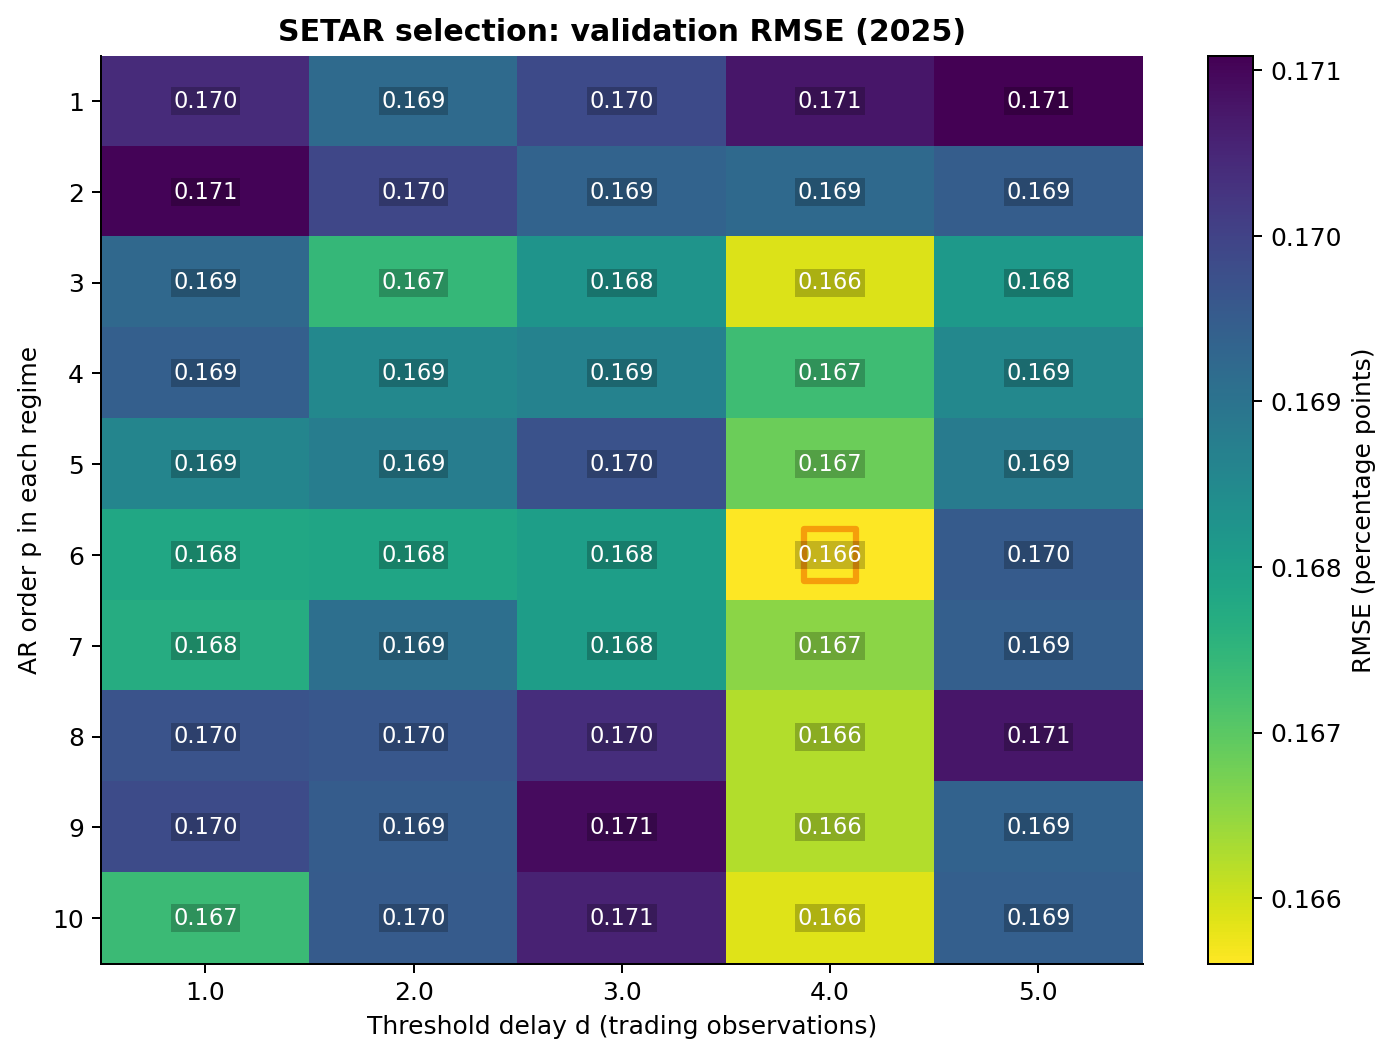

In [3]:
display(grid.sort_values(['RMSE','p','d']).head(15))
print('SETAR chọn:', selected['SETAR'])
display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar/01_validation_grid.png')))

## 5. Ngưỡng và hệ số cuối

Refit gamma/hệ số bằng Train+Validation; p,d giữ nguyên. Các hệ số không được thay đổi khi Test đi qua từng phiên.

,Fit_data,Model,Regime,Term,Estimate
0,train,AR,All,Intercept,0.003680
1,train,AR,All,lag_1,0.098697
2,train,AR,All,lag_2,-0.038263
3,train,AR,All,lag_3,0.125574
4,train,AR,All,lag_4,0.095499
5,train,AR,All,lag_5,-0.003996
6,train,AR,All,lag_6,0.066779
7,train,AR,All,lag_7,0.006311
8,train,SETAR,Low,Intercept,0.029508
9,train,SETAR,Low,lag_1,0.123372


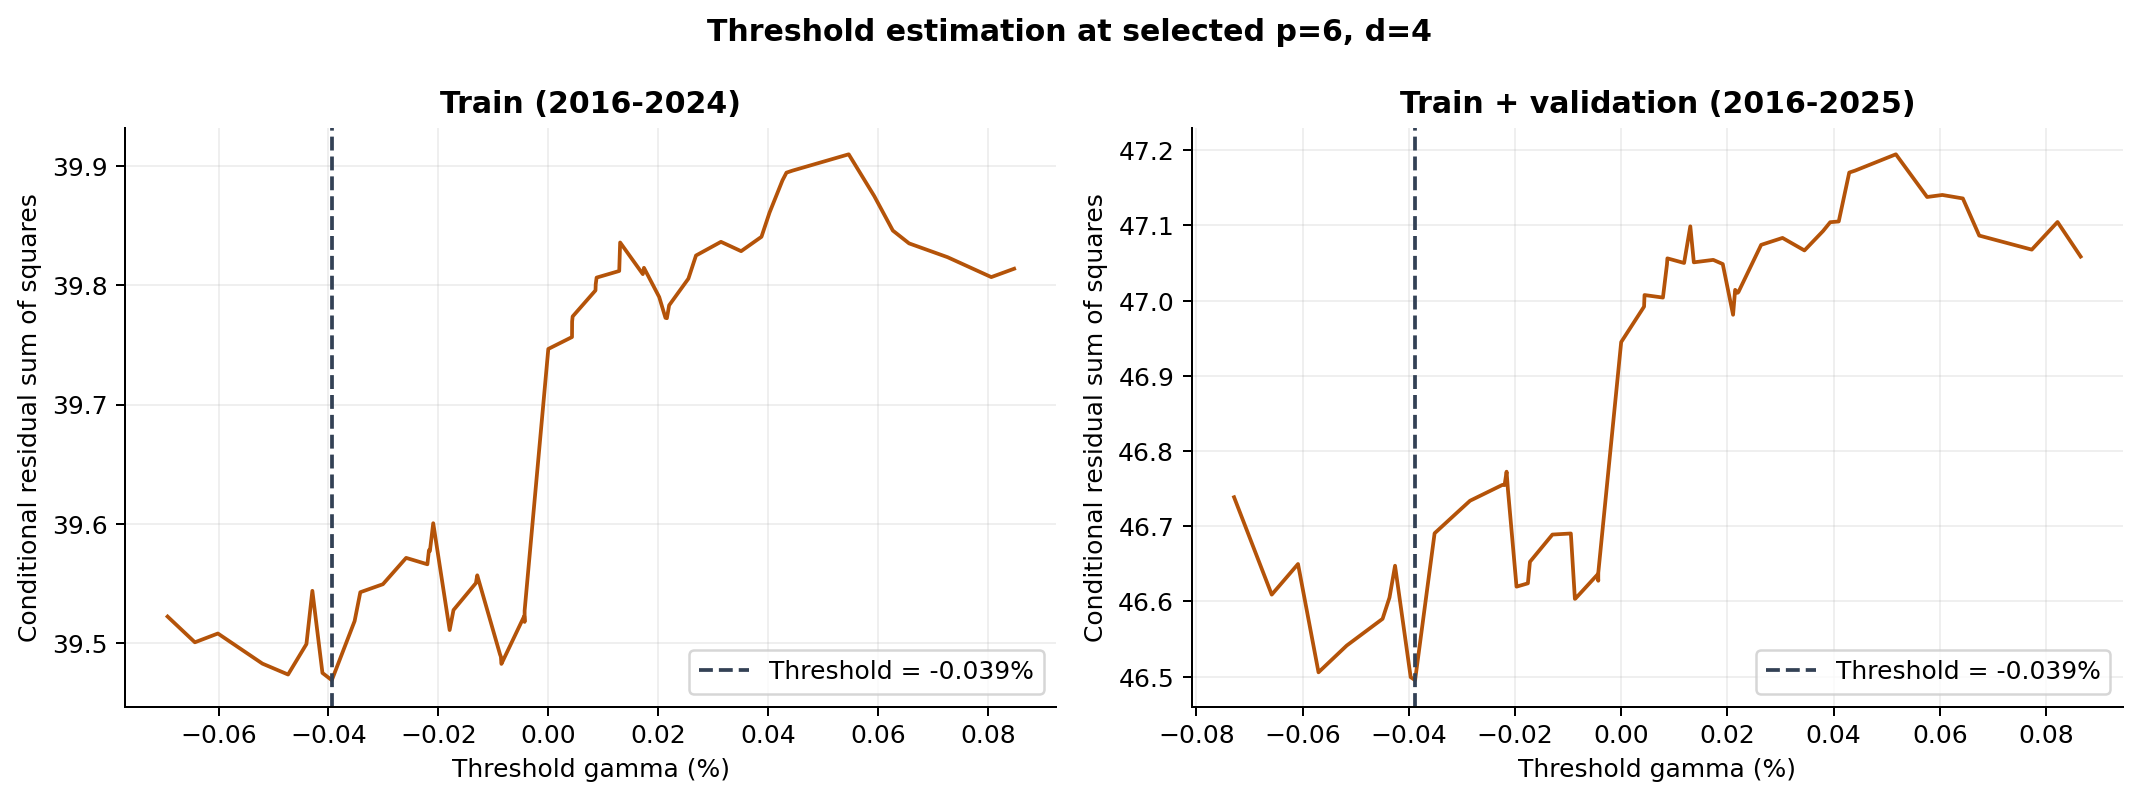

In [4]:
display(tables['coefficients.csv'])
display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar/02_threshold_profile.png')))

## 6. Dự báo return và chế độ trên Test

Chế độ tại t dùng r_(t−d). Các phiên Test đã xảy ra được dùng làm lag cho phiên sau. Đây là **rolling one-step**, không phải dự báo toàn bộ 2026 từ cuối 2025.

,Date,actual_return,actual_close,Zero,Mean,AR,threshold_variable,SETAR_regime,SETAR,previous_close,Zero_price_point,Mean_price_point,AR_price_point,SETAR_price_point,SETAR_return_pi_lower,SETAR_return_pi_upper,SETAR_price_pi_lower,SETAR_price_pi_upper,Split,Zero_price_plugin,Zero_smearing_factor,Mean_price_plugin,Mean_smearing_factor,AR_price_plugin,AR_smearing_factor,SETAR_price_plugin,SETAR_smearing_factor
262,2026-01-01,0.000000,26300.0,0.0,0.006113,0.018620,0.041848,High,0.024886,26300.0,26300.0,26301.632857,26304.921344,26306.566125,-0.231452,0.294678,26239.198546,26377.614713,test,26300.0,1.0,26301.607870,1.000001,26304.897398,1.000001,26306.545961,1.000001
263,2026-01-02,0.000000,26300.0,0.0,0.006113,-0.026375,-0.022824,High,-0.026090,26300.0,26300.0,26301.632857,26293.088288,26293.159255,-0.282429,0.243701,26225.826010,26364.171634,test,26300.0,1.0,26301.607870,1.000001,26293.064352,1.000001,26293.139101,1.000001
264,2026-01-05,-0.097005,26274.5,0.0,0.006113,0.014831,-0.076118,Low,0.044011,26300.0,26300.0,26301.632857,26303.924916,26311.611651,-0.267280,0.391051,26229.799160,26403.047703,test,26300.0,1.0,26301.607870,1.000001,26303.900971,1.000001,26311.577413,1.000001
265,2026-01-06,0.003806,26275.5,0.0,0.006113,0.006910,0.133168,High,0.009696,26274.5,26274.5,26276.131274,26276.339635,26277.067771,-0.246643,0.279488,26209.775733,26348.036690,test,26274.5,1.0,26276.106311,1.000001,26276.315714,1.000001,26277.047629,1.000001
266,2026-01-07,-0.005709,26274.0,0.0,0.006113,0.003122,0.000000,High,0.000875,26275.5,26275.5,26277.131336,26276.344262,26275.750036,-0.255463,0.270667,26208.461373,26346.715396,test,26275.5,1.0,26277.106372,1.000001,26276.320341,1.000001,26275.729896,1.000001
267,2026-01-08,-0.015225,26270.0,0.0,0.006113,-0.000165,0.000000,High,0.000218,26274.0,26274.0,26275.631243,26273.980468,26274.077314,-0.256121,0.270009,26206.792935,26345.038156,test,26274.0,1.0,26275.606280,1.000001,26273.956549,1.000001,26274.057174,1.000001
268,2026-01-09,0.000000,26270.0,0.0,0.006113,-0.002262,-0.097005,Low,0.008321,26270.0,26270.0,26271.630995,26269.429733,26272.220268,-0.302970,0.355361,26190.530259,26363.519430,test,26270.0,1.0,26271.606036,1.000001,26269.405819,1.000001,26272.186081,1.000001
269,2026-01-10,-0.057116,26255.0,0.0,0.006113,0.005592,0.003806,High,0.006666,26270.0,26270.0,26271.630995,26271.492921,26271.771485,-0.249672,0.276458,26204.493011,26342.726100,test,26270.0,1.0,26271.606036,1.000001,26271.469005,1.000001,26271.751348,1.000001
270,2026-01-12,0.076147,26275.0,0.0,0.006113,-0.009962,-0.005709,High,-0.009009,26255.0,26255.0,26256.630064,26252.408564,26252.655001,-0.265347,0.260783,26185.425482,26323.557987,test,26255.0,1.0,26256.605119,1.000001,26252.384665,1.000001,26252.634878,1.000001
271,2026-01-13,0.047562,26287.5,0.0,0.006113,0.011500,-0.015225,High,0.010632,26275.0,26275.0,26276.631305,26278.045753,26277.813803,-0.245707,0.280424,26210.519855,26348.784737,test,26275.0,1.0,26276.606341,1.000001,26278.021831,1.000001,26277.793661,1.000001


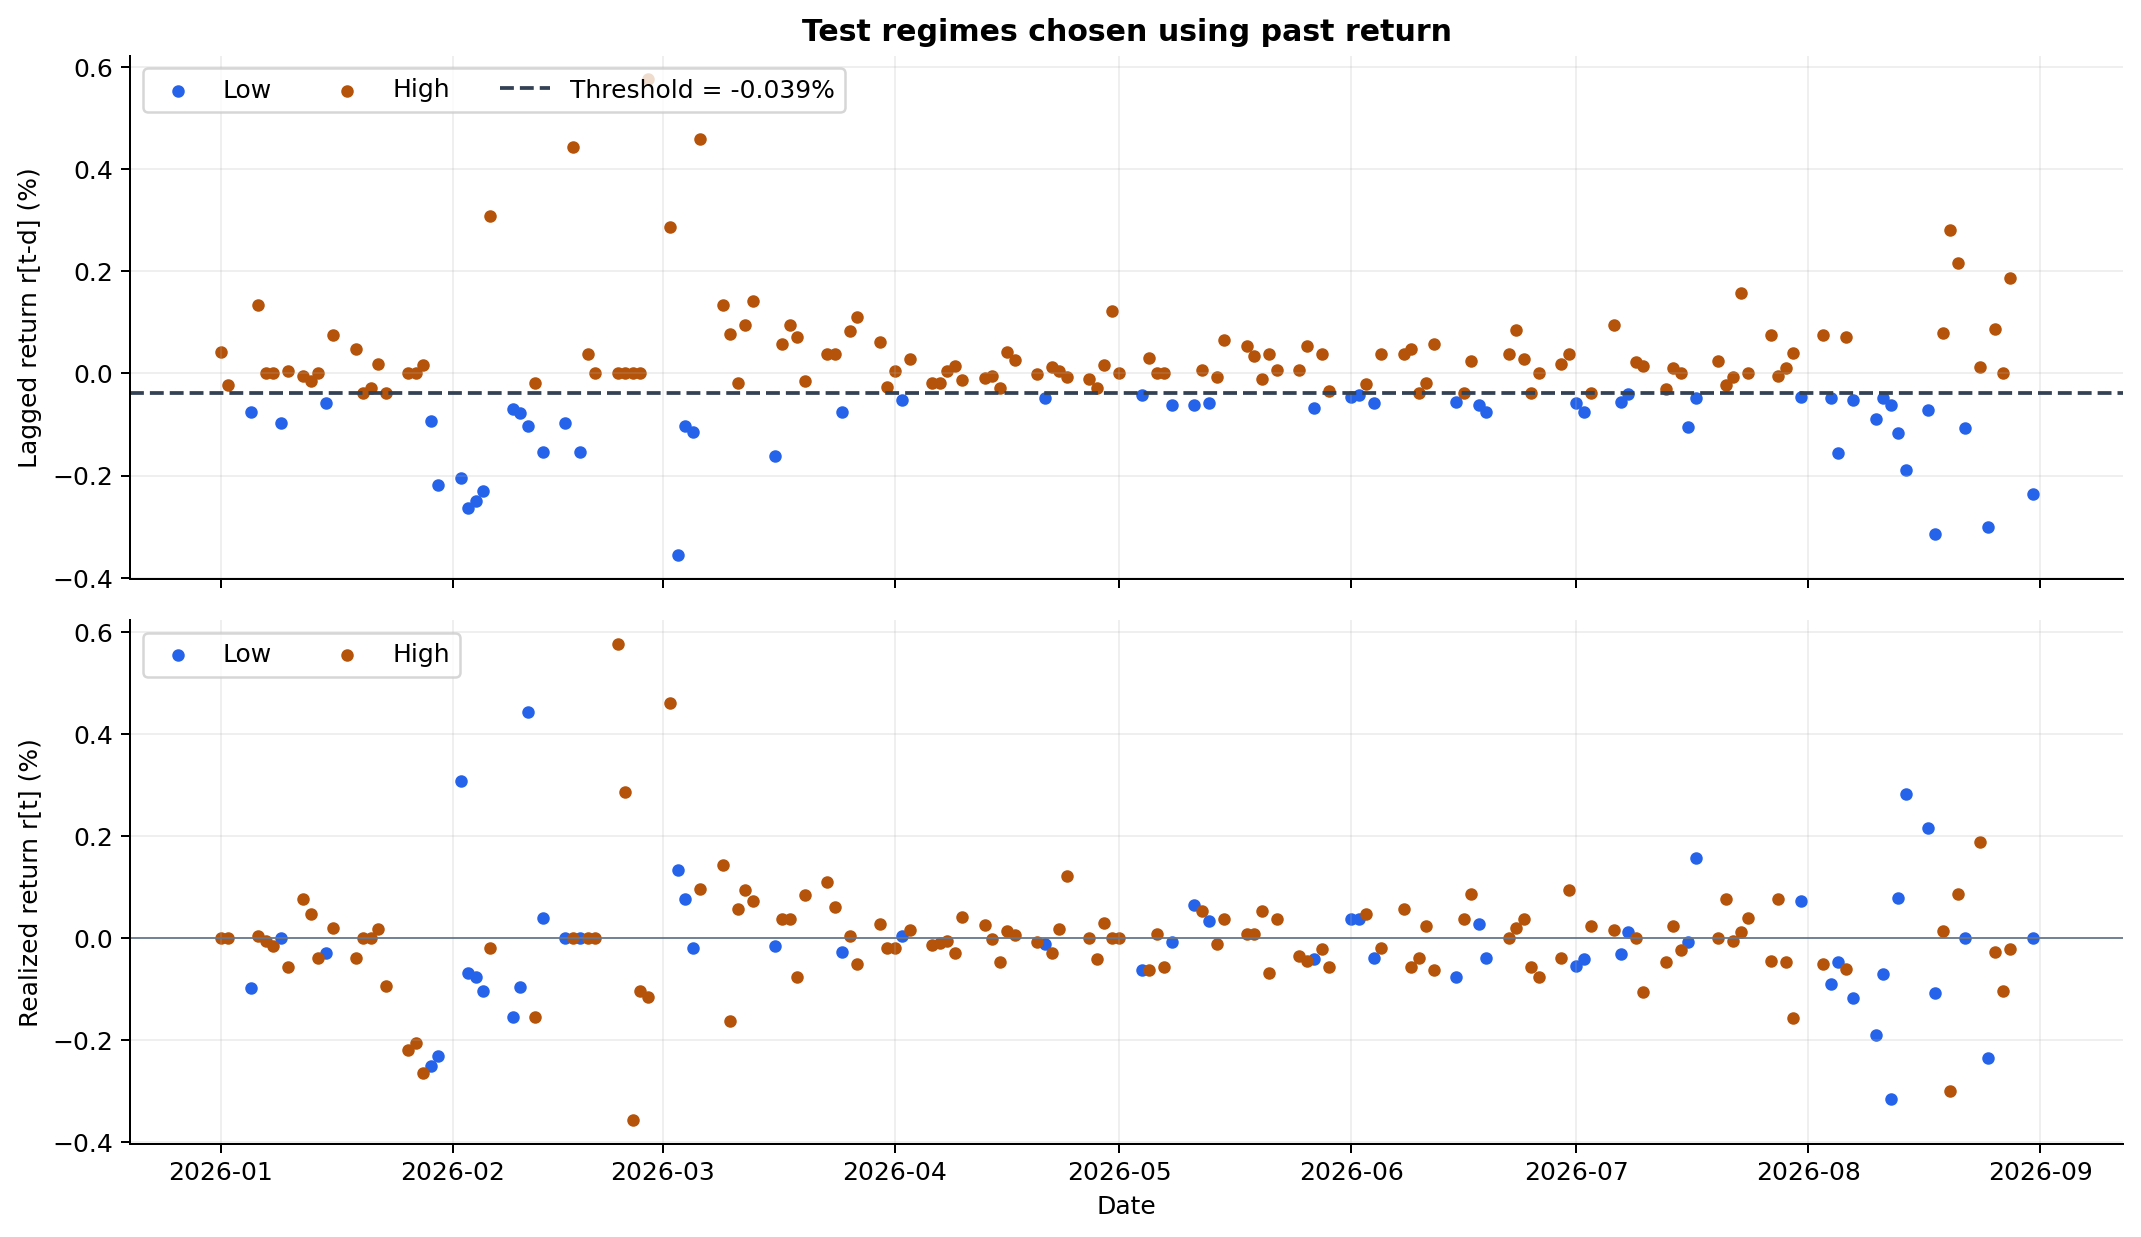

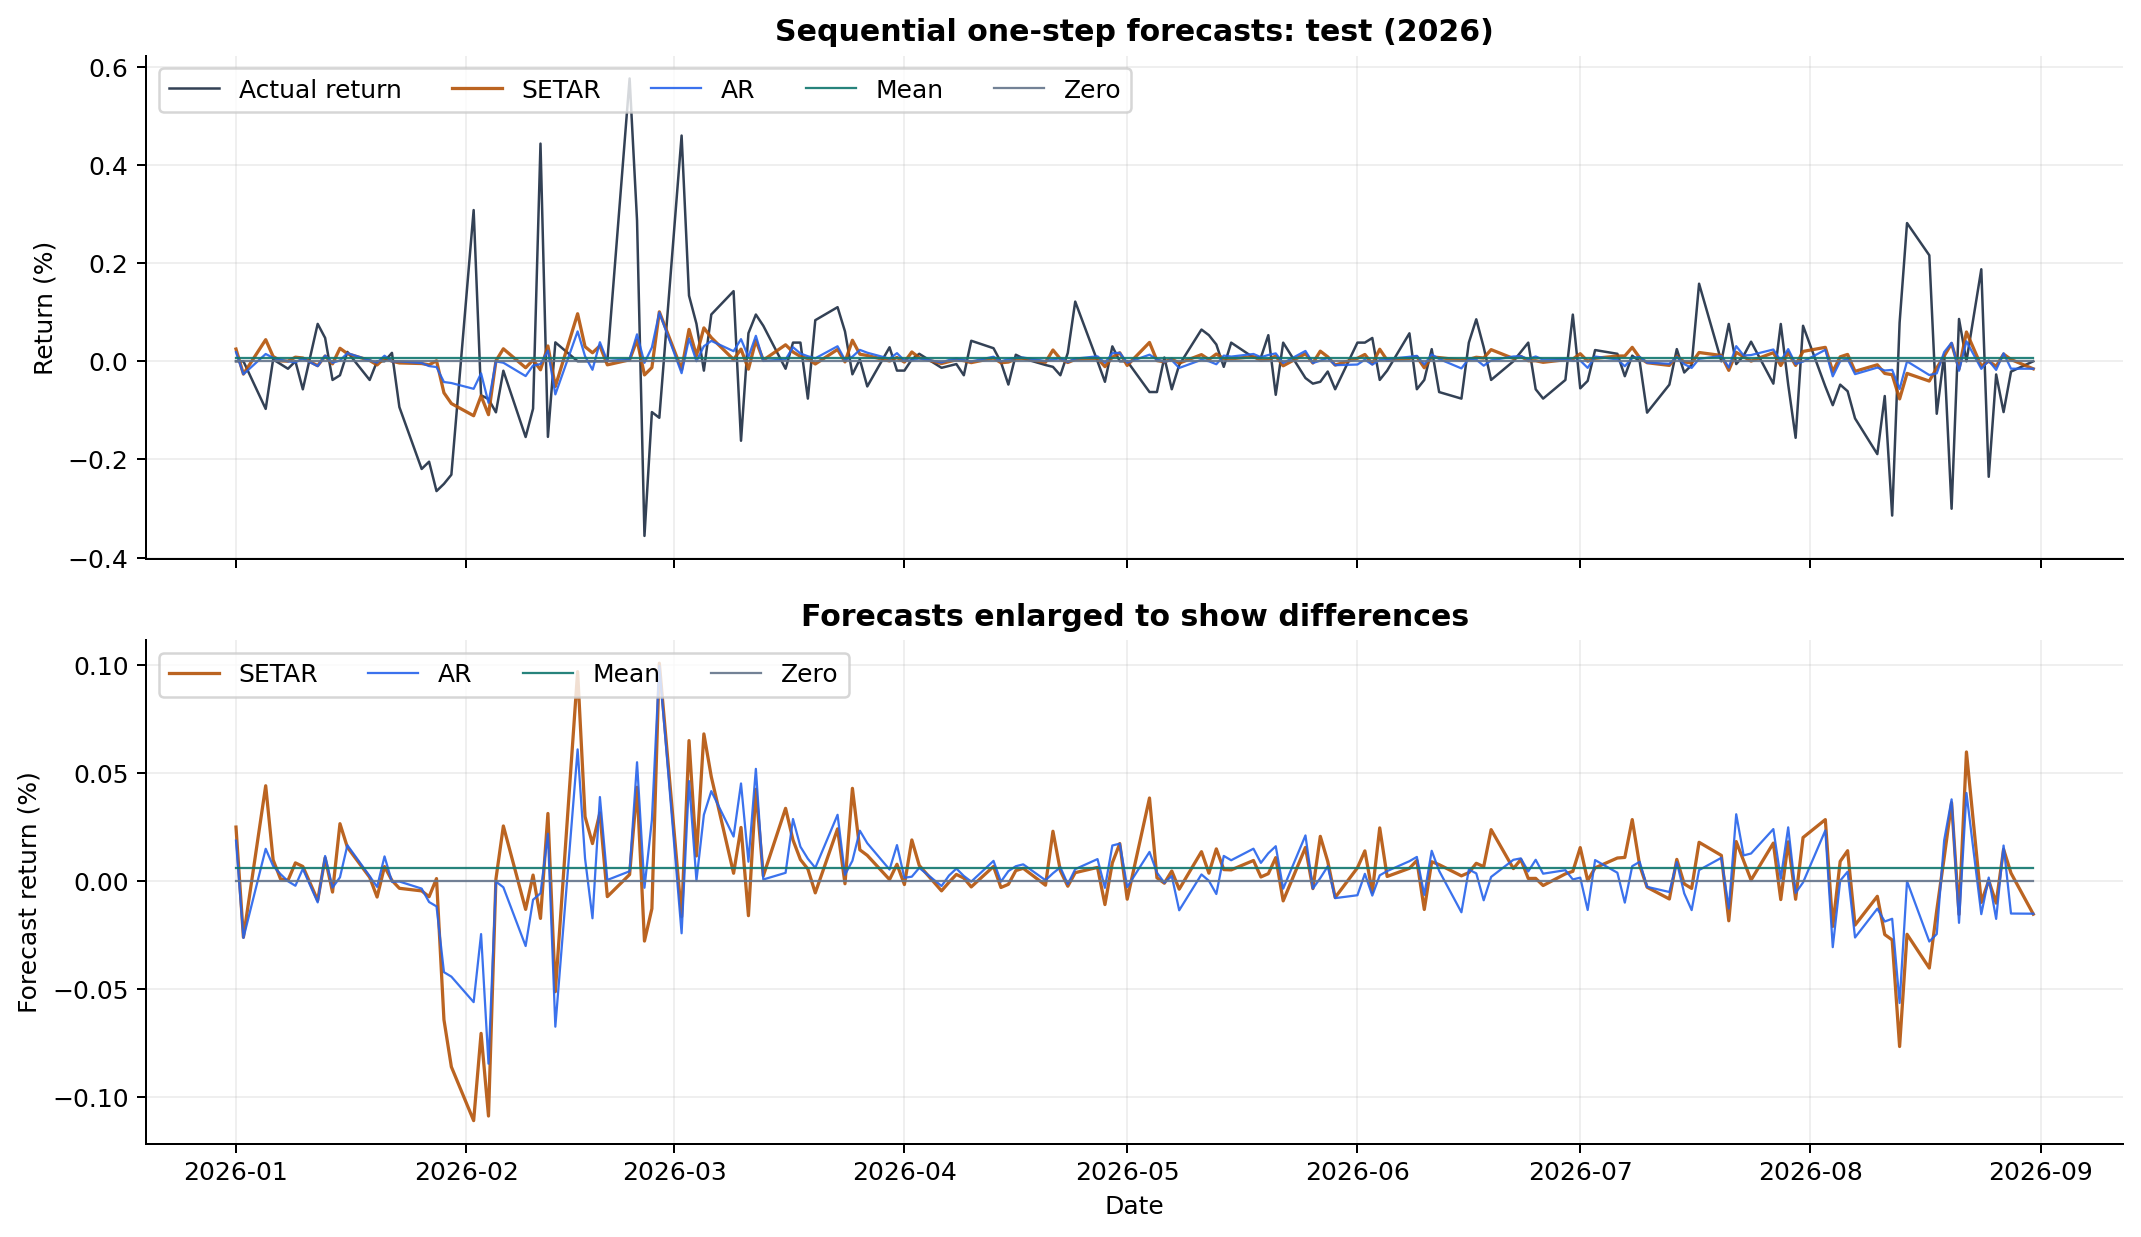

In [5]:
display(evaluation['predictions'].query("Split == 'test'").head(10))
for name in ['03_test_regimes.png','04_test_forecasts.png']:
    display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar'/name)))

## 7. Chỉ số return

MAE, MSE, RMSE, median/max absolute error, bias, out-of-sample R², MASE, relative RMSE, WAPE và dự báo hướng. Đơn vị MAE/RMSE là **điểm phần trăm**.

MAPE/sMAPE return để trống vì target có 0/gần 0 và giá trị âm. MASE return dùng persistence return trong mẫu fit; relative RMSE dùng Zero return trên đúng tập đánh giá.

,Split,Model,N,MAE,MSE,RMSE,Median_AE,Max_AE,Bias_actual_minus_forecast,R2_out_of_sample,MASE,MASE_training_scale,Naive_RMSE,Relative_RMSE_vs_Naive,RMSE_improvement_vs_Naive_percent,DA_all_percent,DA_nonzero_actual_percent,Balanced_direction_accuracy_percent,Actual_down_N,Actual_flat_N,Actual_up_N,MAPE_percent,sMAPE_percent,WAPE_percent,Direction_accuracy
0,validation,Zero,262,0.097492,0.028423,0.168590,0.056931,0.874062,0.012090,-0.005169,0.915013,0.106547,0.16859,1.000000,0.000000,8.396947,0.000000,33.333333,116,22,124,NaN,NaN,100.000000,0.083969
1,validation,Mean,262,0.097876,0.028321,0.168287,0.055297,0.868616,0.006644,-0.001561,0.918620,0.106547,0.16859,0.998204,0.179634,47.328244,51.666667,33.333333,116,22,124,NaN,NaN,100.394191,0.473282
2,validation,AR,262,0.100433,0.027947,0.167174,0.058449,0.874954,0.004009,0.011655,0.942614,0.106547,0.16859,0.991596,0.840402,42.366412,46.250000,30.487579,116,22,124,NaN,NaN,103.016428,0.423664
3,validation,SETAR,262,0.100953,0.027425,0.165605,0.058545,0.874469,0.003928,0.030115,0.947493,0.106547,0.16859,0.982292,1.770793,43.893130,47.916667,31.414535,116,22,124,NaN,NaN,103.549617,0.438931
4,test,Zero,175,0.070908,0.013246,0.115090,0.039931,0.575928,-0.004964,-0.001864,0.642222,0.110410,0.11509,1.000000,0.000000,10.285714,0.000000,33.333333,87,18,70,NaN,NaN,100.000000,0.102857
5,test,Mean,175,0.072214,0.013344,0.115516,0.044143,0.569814,-0.011078,-0.009282,0.654058,0.110410,0.11509,1.003695,-0.369522,40.000000,44.585987,33.333333,87,18,70,NaN,NaN,101.842944,0.400000
6,test,AR,175,0.072180,0.013559,0.116444,0.042120,0.571481,-0.007955,-0.025580,0.653748,0.110410,0.11509,1.011767,-1.176660,49.714286,55.414013,37.892720,87,18,70,NaN,NaN,101.794700,0.497143
7,test,SETAR,175,0.074411,0.013977,0.118224,0.047196,0.572989,-0.008684,-0.057158,0.673957,0.110410,0.11509,1.027225,-2.722513,48.571429,54.140127,37.219485,87,18,70,NaN,NaN,104.941441,0.485714


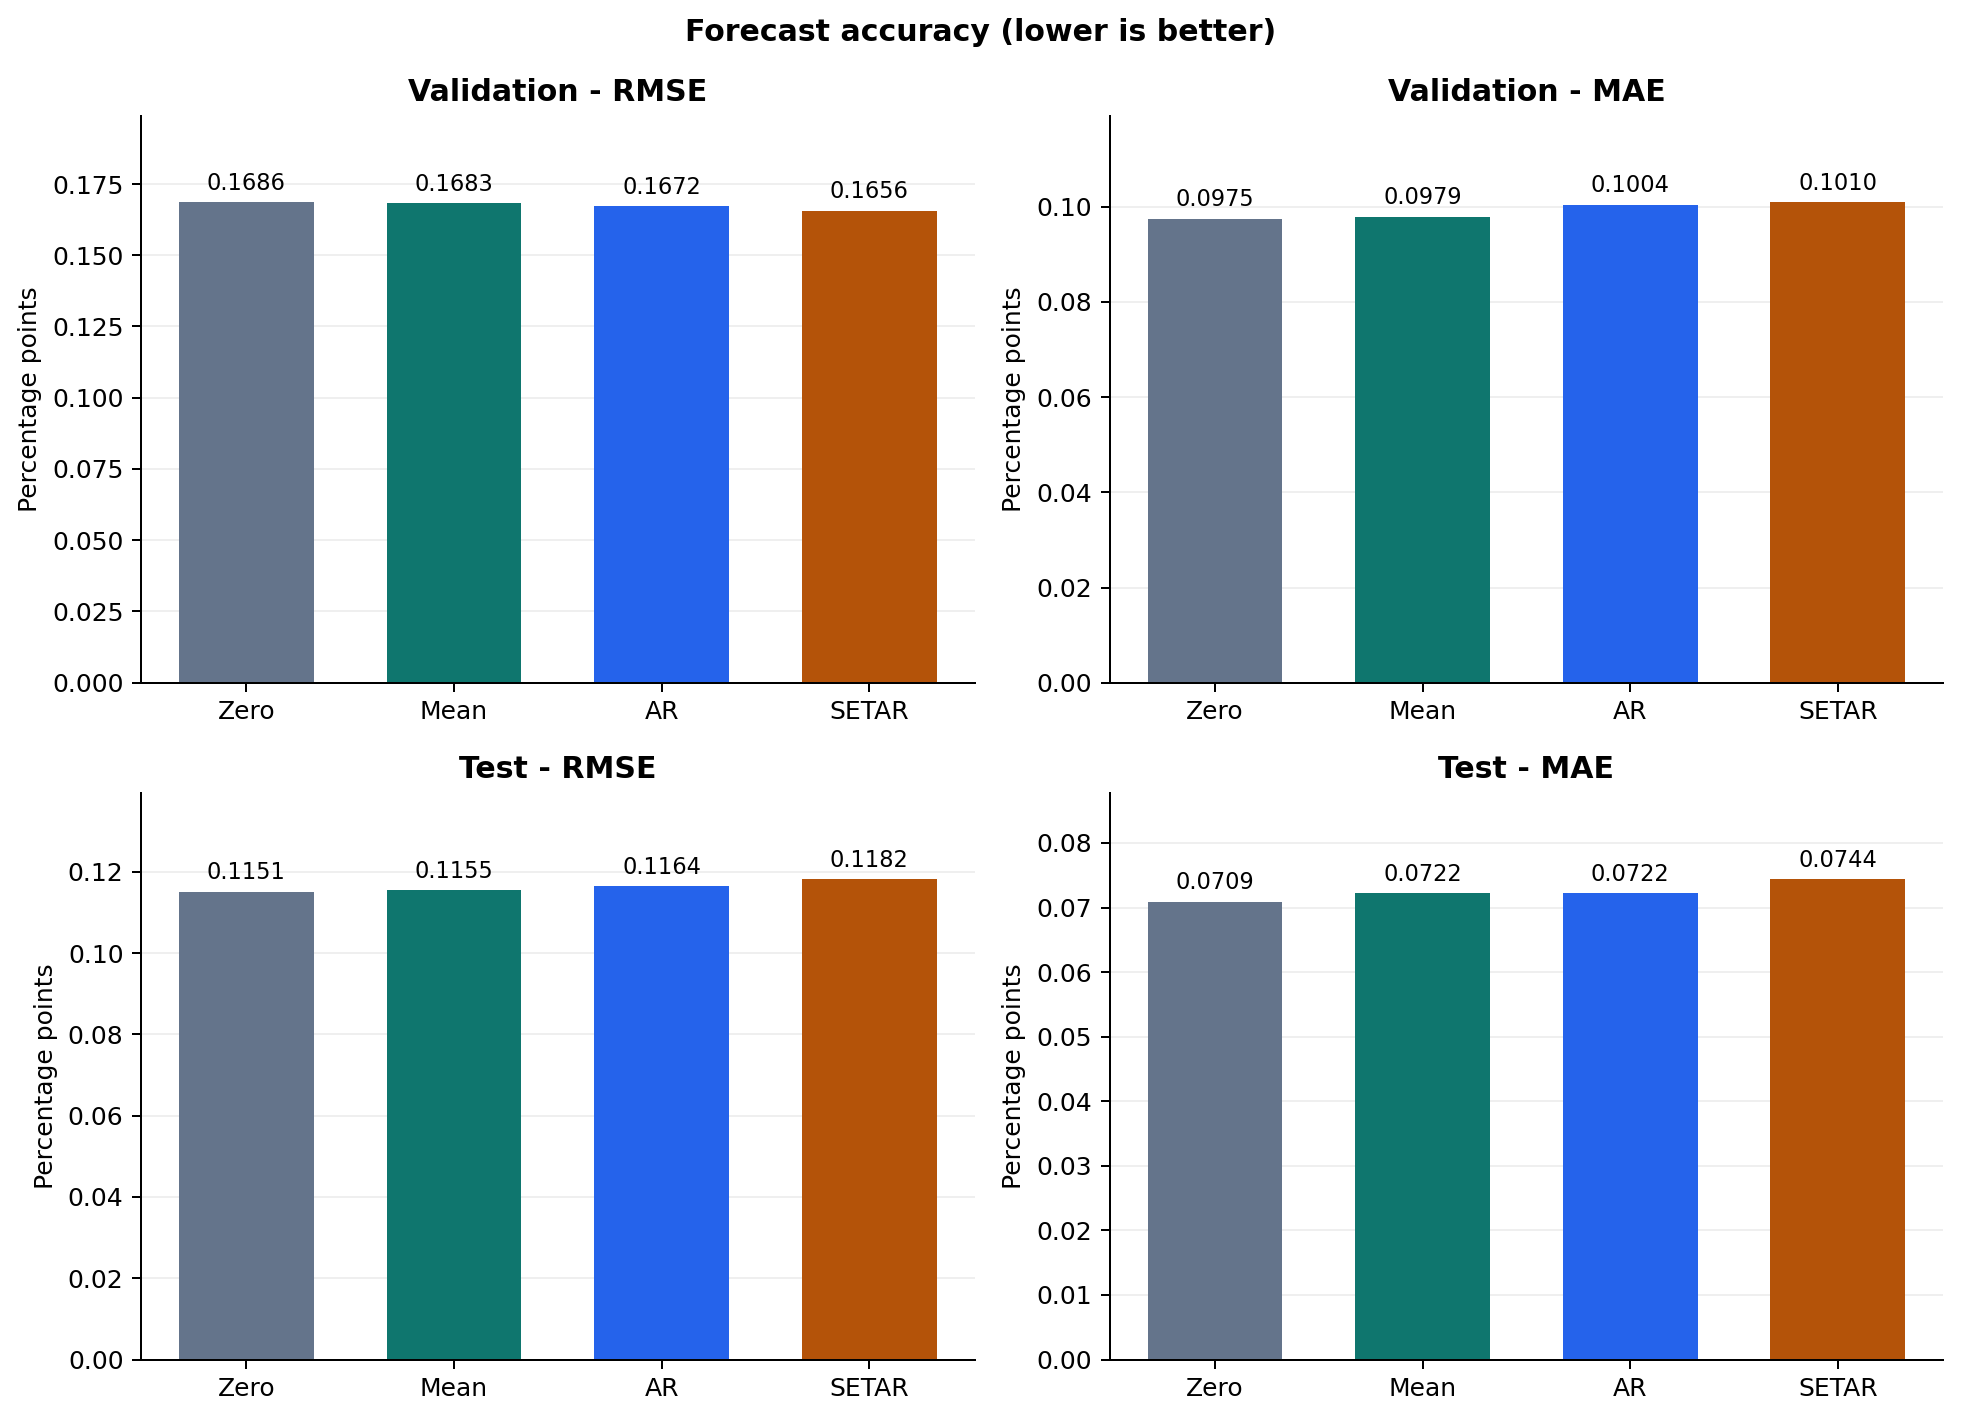

In [6]:
display(evaluation['metrics'])
display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar/05_forecast_metrics.png')))

## 8. Chỉ số tỷ giá

Dự báo tỷ giá dùng giá thật phiên trước và return dự báo, cộng hiệu chỉnh empirical residual smearing theo chế độ. Giá plug-in chưa hiệu chỉnh cũng được lưu. Hiệu chỉnh chỉ dùng mẫu fit.

MAE/RMSE trên thang VND/USD; MAPE/sMAPE trên giá; MASE dùng sai số Naive trong mẫu fit; relative RMSE dùng Naive trên Test.

,Split,Model,Point_forecast,N,MAE,MSE,RMSE,Median_AE,Max_AE,Bias_actual_minus_forecast,R2_out_of_sample,MASE,MASE_training_scale,Naive_RMSE,Relative_RMSE_vs_Naive,RMSE_improvement_vs_Naive_percent,DA_all_percent,DA_nonzero_actual_percent,Balanced_direction_accuracy_percent,Actual_down_N,Actual_flat_N,Actual_up_N,MAPE_percent,sMAPE_percent,WAPE_percent,Direction_accuracy
0,validation,Zero,previous_close,262,25.187023,1870.807252,43.252829,15.000000,220.000000,3.129771,0.987564,1.439890,17.492327,43.252829,1.000000,0.000000,8.396947,0.000000,33.333333,116,22,124,0.097463,0.097492,0.096860,0.083969
1,validation,Mean,empirical_mean,262,25.289077,1864.011573,43.174200,14.451375,221.437120,1.690414,0.987609,1.445724,17.492327,43.252829,0.998182,0.181789,47.328244,51.666667,33.333333,116,22,124,0.097861,0.097884,0.097252,0.473282
2,validation,AR,empirical_mean,262,25.941585,1840.016113,42.895409,15.372830,220.202152,1.001606,0.987769,1.483027,17.492327,43.252829,0.991736,0.826352,42.748092,46.666667,30.756396,116,22,124,0.100420,0.100433,0.099762,0.427481
3,validation,SETAR,empirical_mean,262,26.071270,1803.966237,42.473124,15.305720,220.084146,0.969452,0.988008,1.490440,17.492327,43.252829,0.981973,1.802670,43.893130,47.916667,31.414535,116,22,124,0.100942,0.100956,0.100260,0.438931
4,test,Zero,previous_close,175,18.562857,903.207143,30.053405,10.500000,150.000000,-1.300000,0.936698,1.016289,18.265337,30.053405,1.000000,0.000000,10.285714,0.000000,33.333333,87,18,70,0.070899,0.070908,0.070722,0.102857
5,test,Mean,empirical_mean,175,18.911548,910.146226,30.168630,11.634720,148.387631,-2.929689,0.936212,1.035379,18.265337,30.053405,1.003834,-0.383401,40.000000,44.585987,33.333333,87,18,70,0.072234,0.072238,0.072050,0.400000
6,test,AR,empirical_mean,175,18.898896,924.528194,30.406055,11.077670,148.821558,-2.115331,0.935204,1.034686,18.265337,30.053405,1.011734,-1.173412,49.714286,55.414013,37.892720,87,18,70,0.072188,0.072196,0.072002,0.497143
7,test,SETAR,empirical_mean,175,19.483811,952.883739,30.868815,12.420188,149.216732,-2.308617,0.933217,1.066710,18.265337,30.053405,1.027132,-2.713204,48.571429,54.140127,37.219485,87,18,70,0.074419,0.074430,0.074231,0.485714


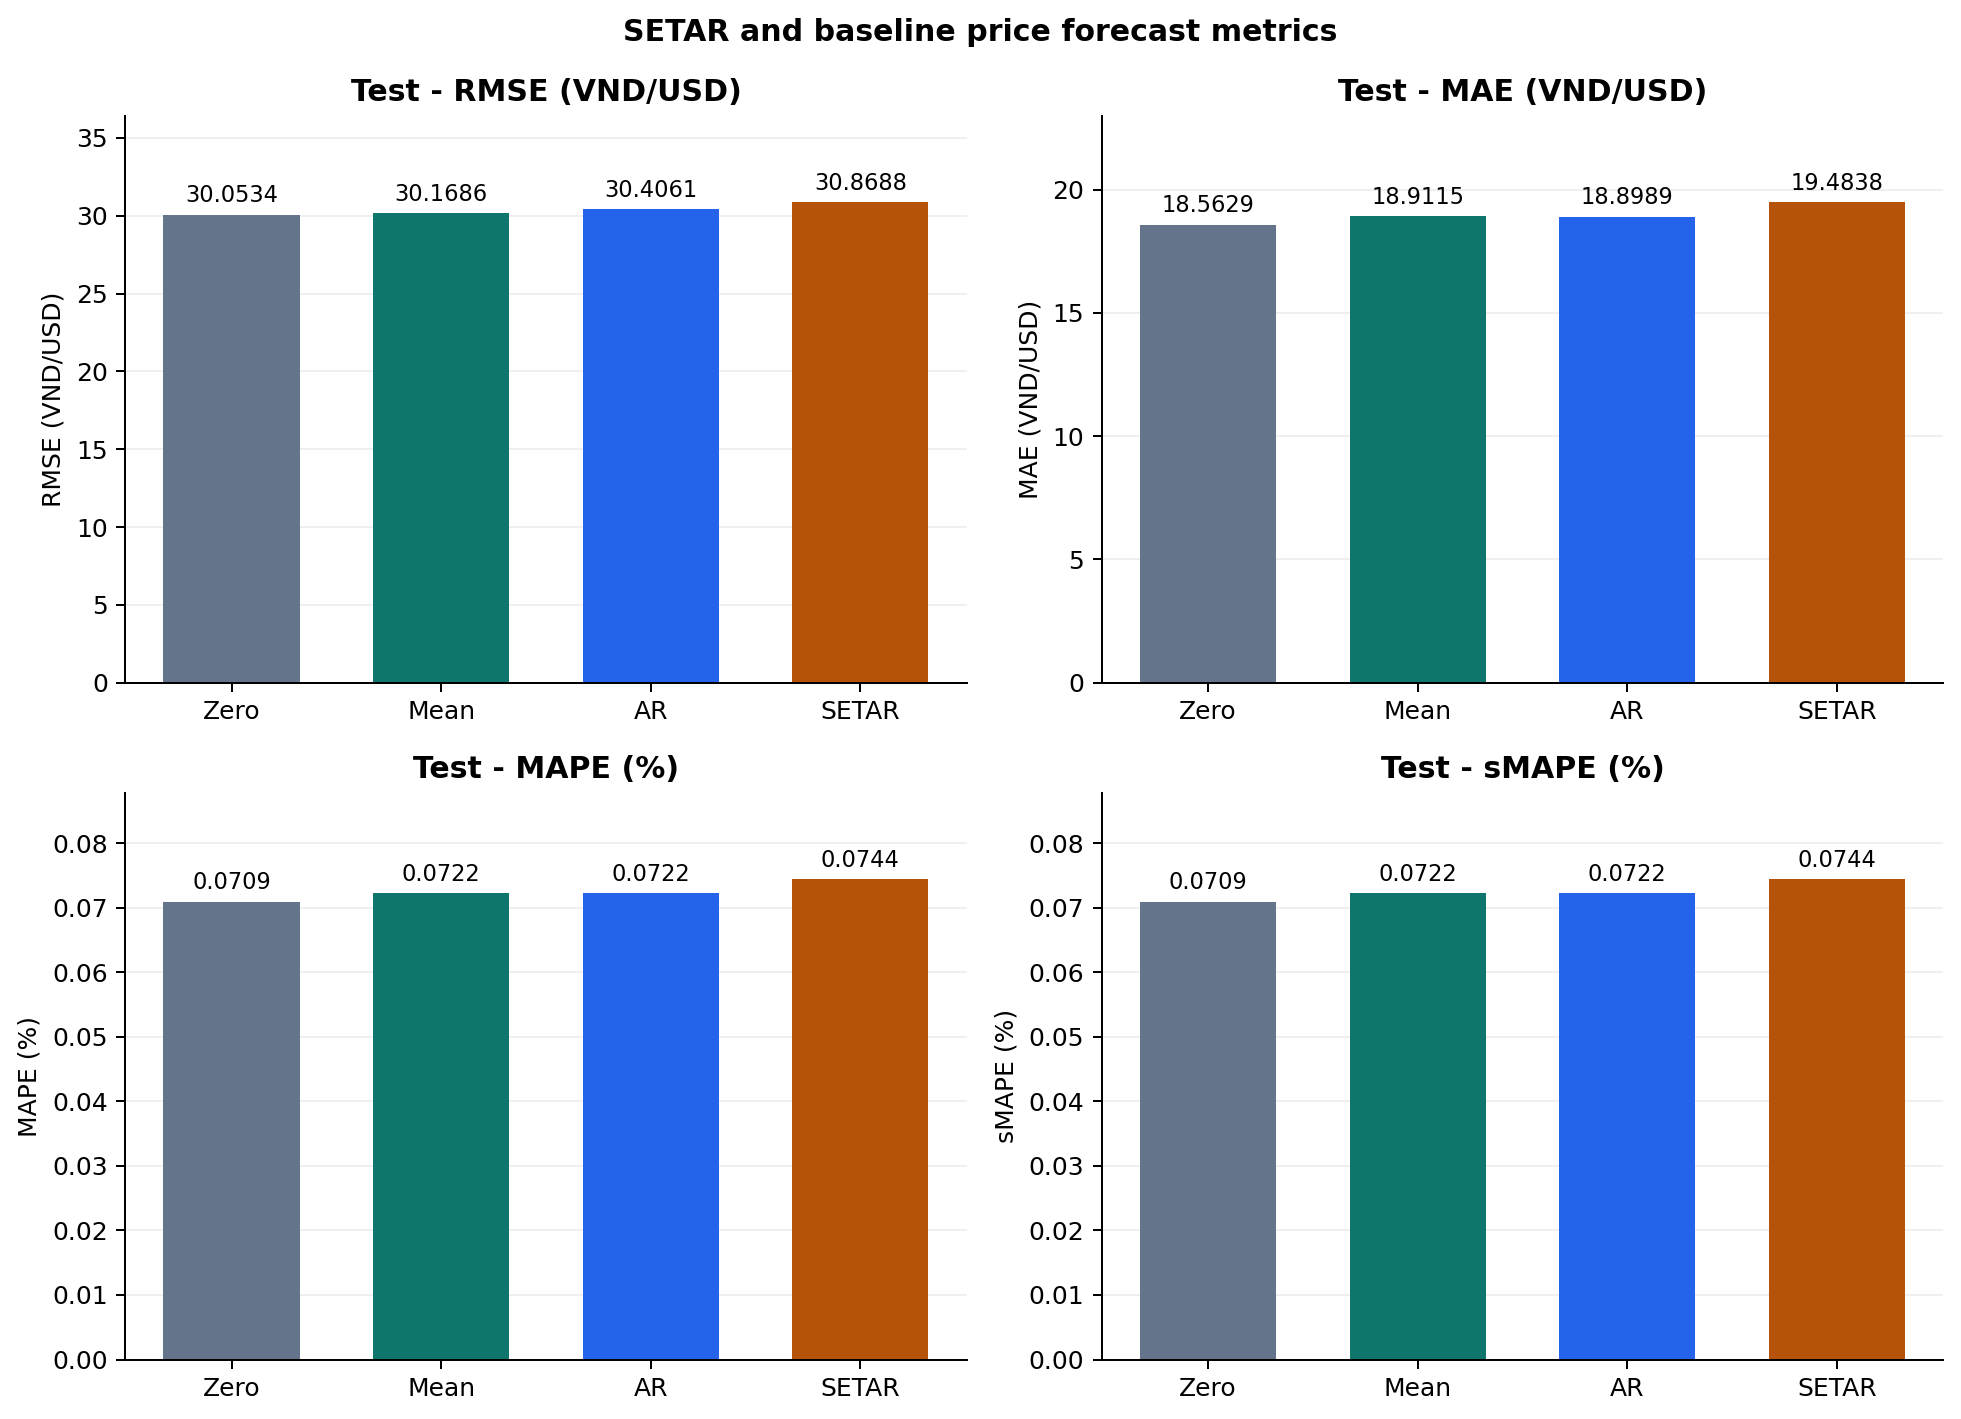

In [7]:
display(evaluation['price_metrics'])
for name in ['08_common_price_metrics.png']:
    display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar'/name)))

## 9. Dự báo hướng

Có ba nhãn down/flat/up; ngoài accuracy toàn bộ còn có accuracy chỉ trên phiên giá thực tế thay đổi và balanced class recall. Naive luôn dự báo flat nên không diễn giải tỷ lệ trúng flat là năng lực dự báo tăng/giảm.

,Model,DA_all_percent,DA_nonzero_actual_percent,Balanced_direction_accuracy_percent,Actual_down_N,Actual_flat_N,Actual_up_N
4,Zero,10.285714,0.000000,33.333333,87,18,70
5,Mean,40.000000,44.585987,33.333333,87,18,70
6,AR,49.714286,55.414013,37.892720,87,18,70
7,SETAR,48.571429,54.140127,37.219485,87,18,70


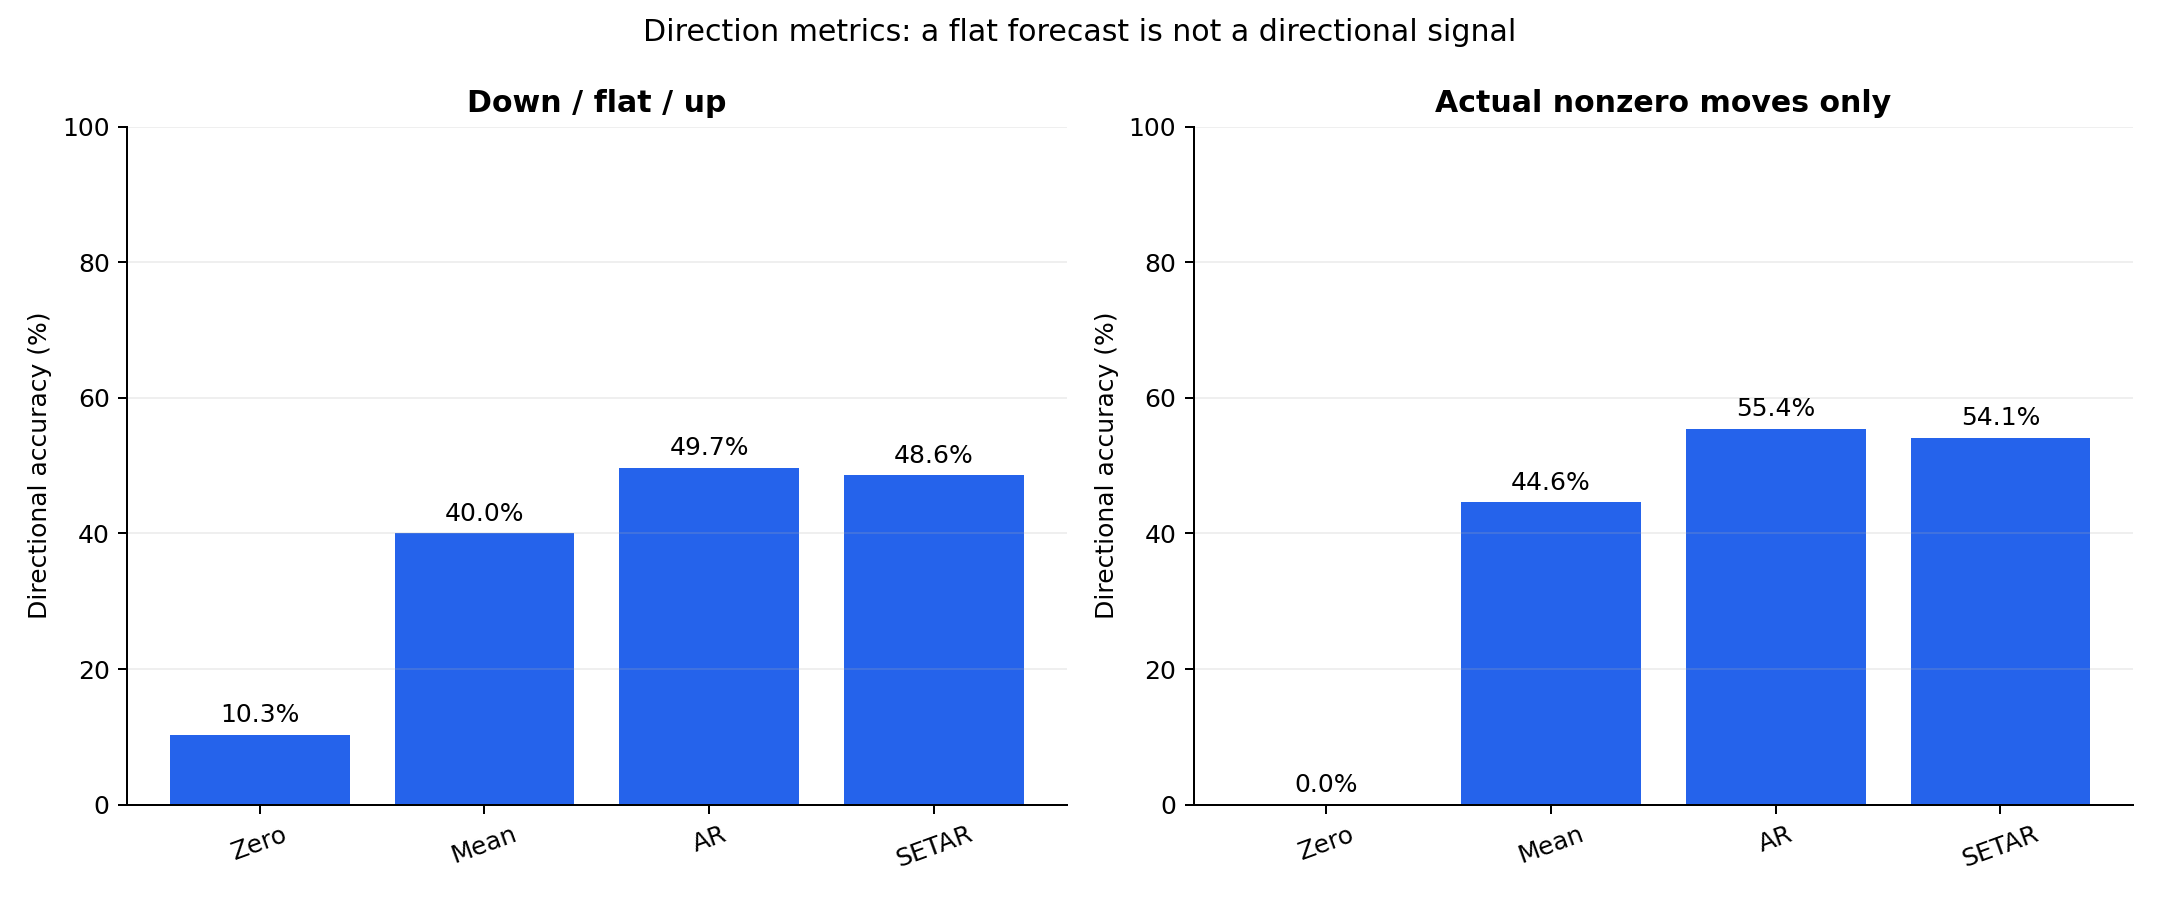

In [8]:
display(evaluation['price_metrics'].query("Split == 'test'")[['Model','DA_all_percent','DA_nonzero_actual_percent','Balanced_direction_accuracy_percent','Actual_down_N','Actual_flat_N','Actual_up_N']])
display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar/11_directional_accuracy.png')))

## 10. Khoảng dự báo 95%

Lấy phân vị residual mẫu fit theo từng chế độ, không hiệu chỉnh bằng Test. Báo cáo coverage, độ rộng và interval score. Khoảng xấp xỉ, chưa bao gồm bất định tham số/ngưỡng hoặc mô hình hóa biến động phương sai.

,Split,Model,Scale,Nominal_coverage_percent,PI_coverage_percent,Average_PI_width,Mean_interval_score,Below_lower_N,Above_upper_N
0,validation,SETAR,return_percent,95.0,93.129771,0.545206,1.133663,7,11
1,validation,SETAR,price_VND_per_USD,95.0,93.129771,141.758029,291.973111,7,11
2,test,SETAR,return_percent,95.0,96.000000,0.566168,0.761781,3,4
3,test,SETAR,price_VND_per_USD,95.0,96.000000,148.611350,199.629748,3,4


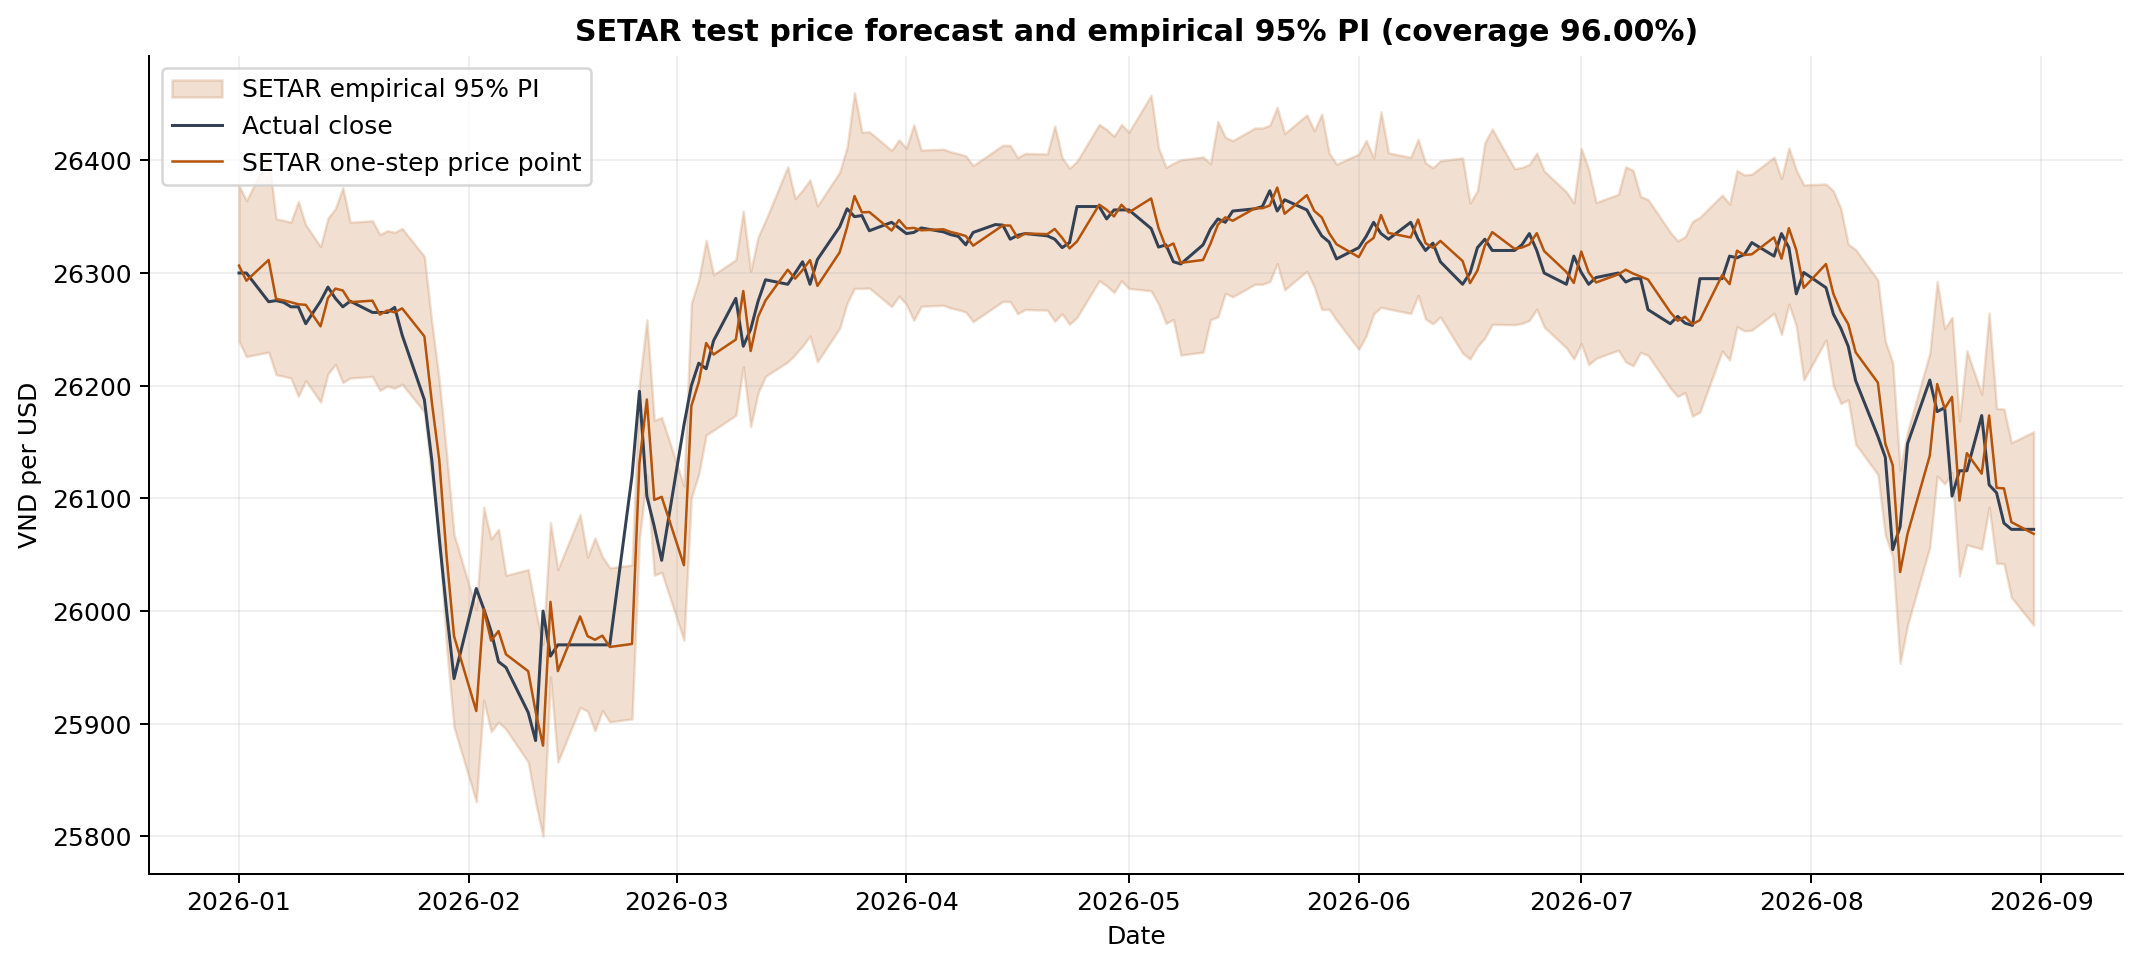

In [9]:
display(evaluation['interval_metrics'])
display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar/09_test_price_prediction_interval.png')))

## 11. Chẩn đoán residual và forecast error

Ljung–Box residual/residual bình phương ở lag 5,10,20; ARCH-LM lag 10; Jarque–Bera. Tách mẫu fit và Test. P-value chỉ mang tính chẩn đoán, chưa hiệu chỉnh nhiều lần; không phải kiểm định có hiệu ứng ngưỡng.

,Model,Test,Lag,Statistic,p_value,Skewness,Kurtosis
0,AR,Ljung-Box residual,5.0,0.019272,9.999973e-01,NaN,NaN
1,AR,Ljung-Box squared residual,5.0,413.473225,3.698853e-87,NaN,NaN
2,AR,Ljung-Box residual,10.0,1.225475,9.995664e-01,NaN,NaN
3,AR,Ljung-Box squared residual,10.0,533.156134,3.599514e-108,NaN,NaN
4,AR,Ljung-Box residual,20.0,5.029554,9.997096e-01,NaN,NaN
5,AR,Ljung-Box squared residual,20.0,561.826019,3.108158e-106,NaN,NaN
6,AR,ARCH-LM residual,10.0,258.285581,9.808970e-50,NaN,NaN
7,AR,Jarque-Bera residual,NaN,19968.747700,0.000000e+00,0.157549,16.578274
8,SETAR,Ljung-Box residual,5.0,0.235626,9.986818e-01,NaN,NaN
9,SETAR,Ljung-Box squared residual,5.0,343.685045,4.004846e-72,NaN,NaN


,Model,Sample,Diagnostic,Lag,Statistic,p_value
0,AR,test,Ljung-Box forecast error,5.0,13.647764,1.800867e-02
1,AR,test,Ljung-Box forecast error,10.0,20.589901,2.414183e-02
2,AR,test,Ljung-Box forecast error,20.0,46.481724,6.919252e-04
3,AR,test,Ljung-Box squared forecast error,5.0,31.774000,6.585921e-06
4,AR,test,Ljung-Box squared forecast error,10.0,49.839006,2.857331e-07
5,AR,test,Ljung-Box squared forecast error,20.0,63.012434,2.410209e-06
6,AR,test,ARCH-LM,10.0,26.388648,3.251181e-03
7,AR,test,Jarque-Bera,NaN,361.103443,3.867085e-79
8,SETAR,test,Ljung-Box forecast error,5.0,14.972726,1.047951e-02
9,SETAR,test,Ljung-Box forecast error,10.0,23.904402,7.858221e-03


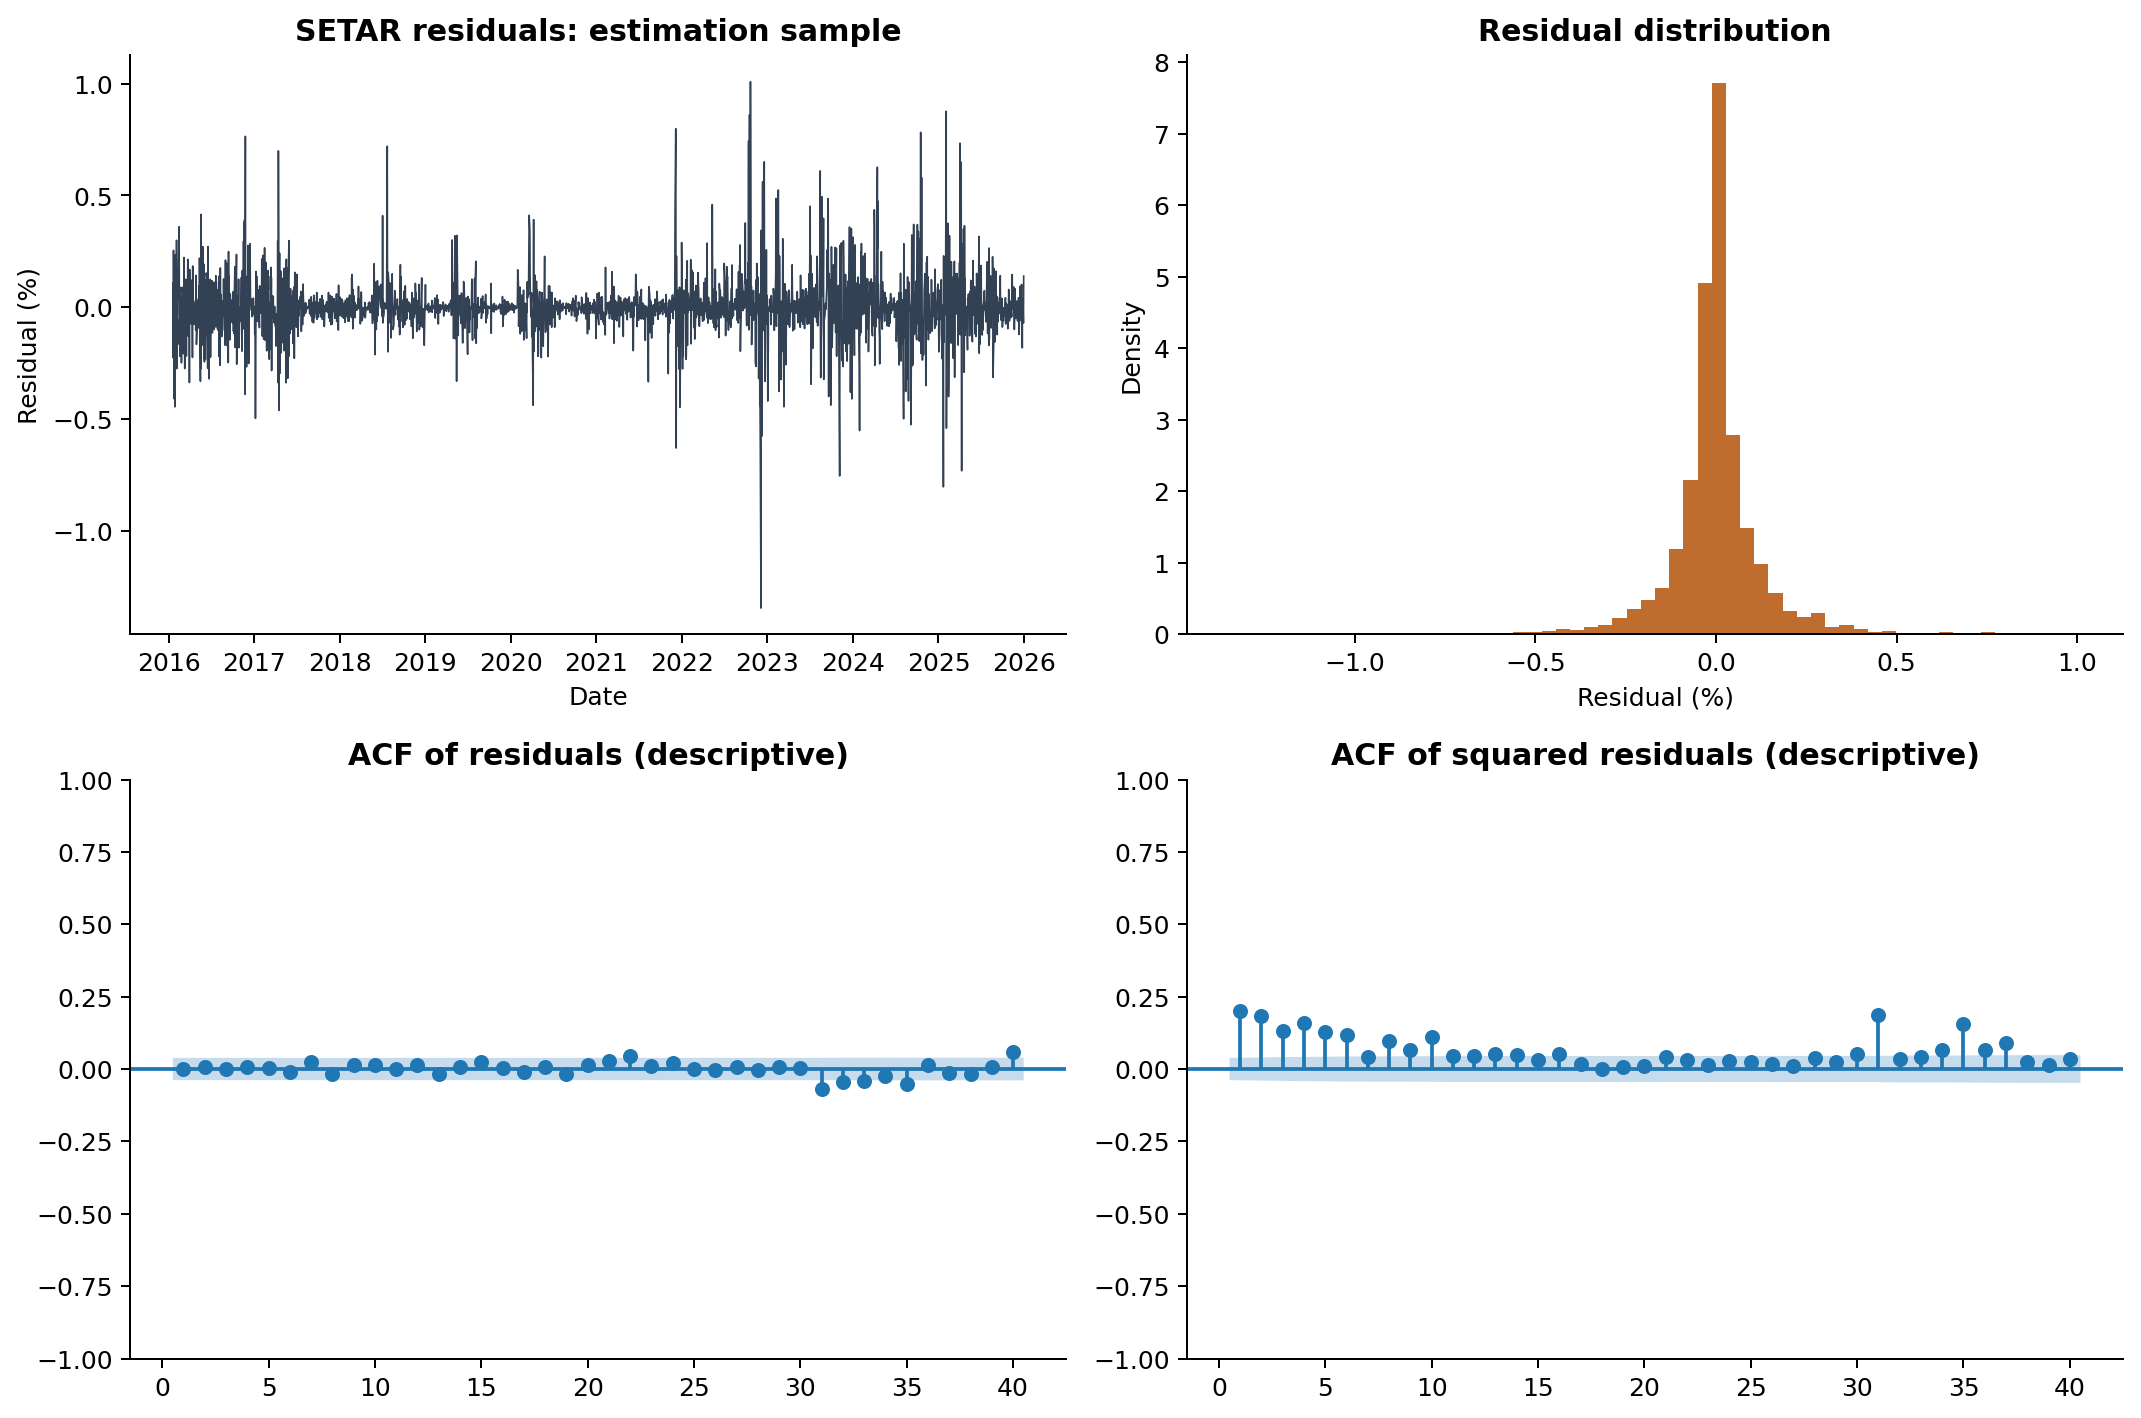

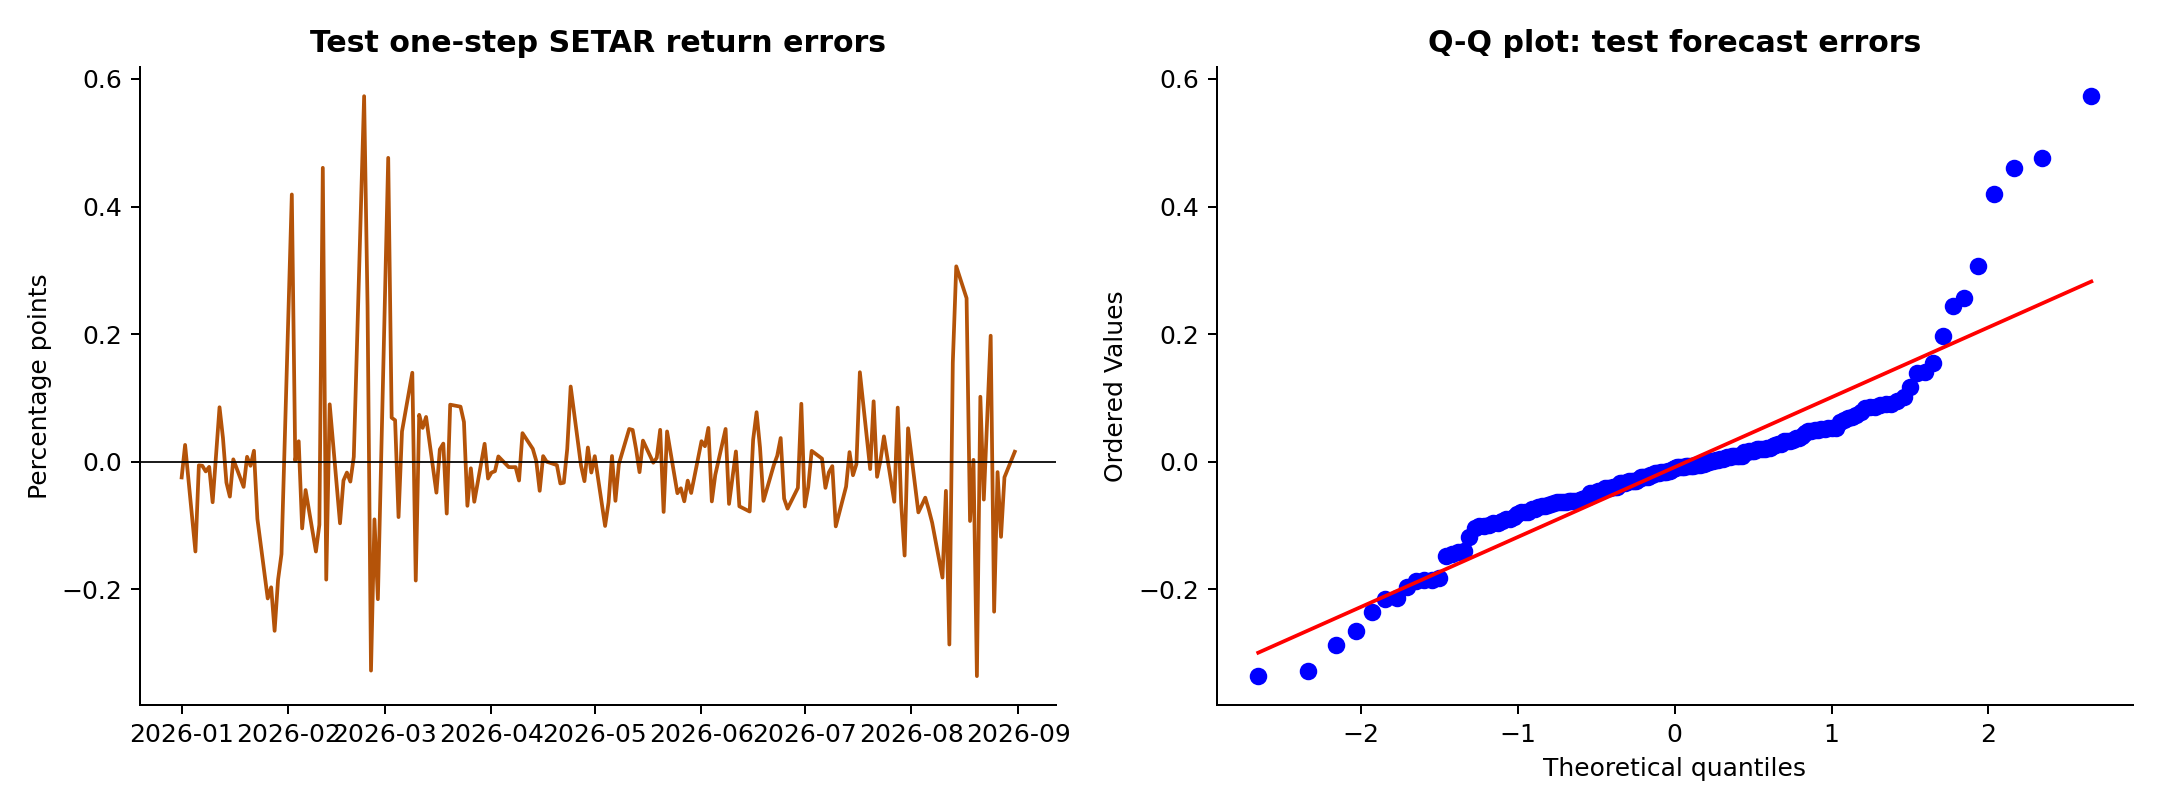

In [10]:
display(tables['residual_diagnostics.csv'])
display(evaluation['test_diagnostics'])
for name in ['07_residual_diagnostics.png','12_test_errors_qq.png']:
    display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar'/name)))

## 12. Chênh lệch sai số và độ chắc chắn

Chênh lệch loss = SETAR − benchmark, dương nghĩa SETAR kém hơn. CI95% bằng paired circular moving-block bootstrap: 2.000 mẫu, block=5, seed cố định. Xem thêm p-value HAC xấp xỉ như thông tin tham khảo; không dùng để chứng minh có phi tuyến/ngưỡng, đặc biệt khi so sánh mô hình lồng nhau.

,Scale,Benchmark,Loss,Mean_loss_difference_SETAR_minus_benchmark,Paired_block_CI95_lower,Paired_block_CI95_upper,HAC_statistic,HAC_normal_two_sided_p_descriptive,Bootstrap_draws,Block_length,HAC_bandwidth,Seed
0,return_percent,Zero,Squared,0.000731,-0.000315,0.001764,1.482227,0.138280,2000,5,5,20261010
1,return_percent,Zero,Absolute,0.003504,-0.000010,0.007343,1.873104,0.061054,2000,5,5,20261010
2,return_percent,Mean,Squared,0.000633,-0.000499,0.001712,1.220188,0.222394,2000,5,5,20261010
3,return_percent,Mean,Absolute,0.002197,-0.001462,0.005912,1.156417,0.247511,2000,5,5,20261010
4,return_percent,AR,Squared,0.000418,-0.000173,0.001043,1.419874,0.155645,2000,5,5,20261010
5,return_percent,AR,Absolute,0.002231,0.000544,0.003986,2.435856,0.014857,2000,5,5,20261010
6,price_VND_per_USD,Zero,Squared,49.676596,-21.509095,118.978092,1.484253,0.137742,2000,5,5,20261010
7,price_VND_per_USD,Zero,Absolute,0.920954,0.004382,1.918589,1.887294,0.059121,2000,5,5,20261010
8,price_VND_per_USD,Mean,Squared,42.737513,-34.199256,115.971102,1.212804,0.225205,2000,5,5,20261010
9,price_VND_per_USD,Mean,Absolute,0.572263,-0.381686,1.545402,1.154635,0.248240,2000,5,5,20261010


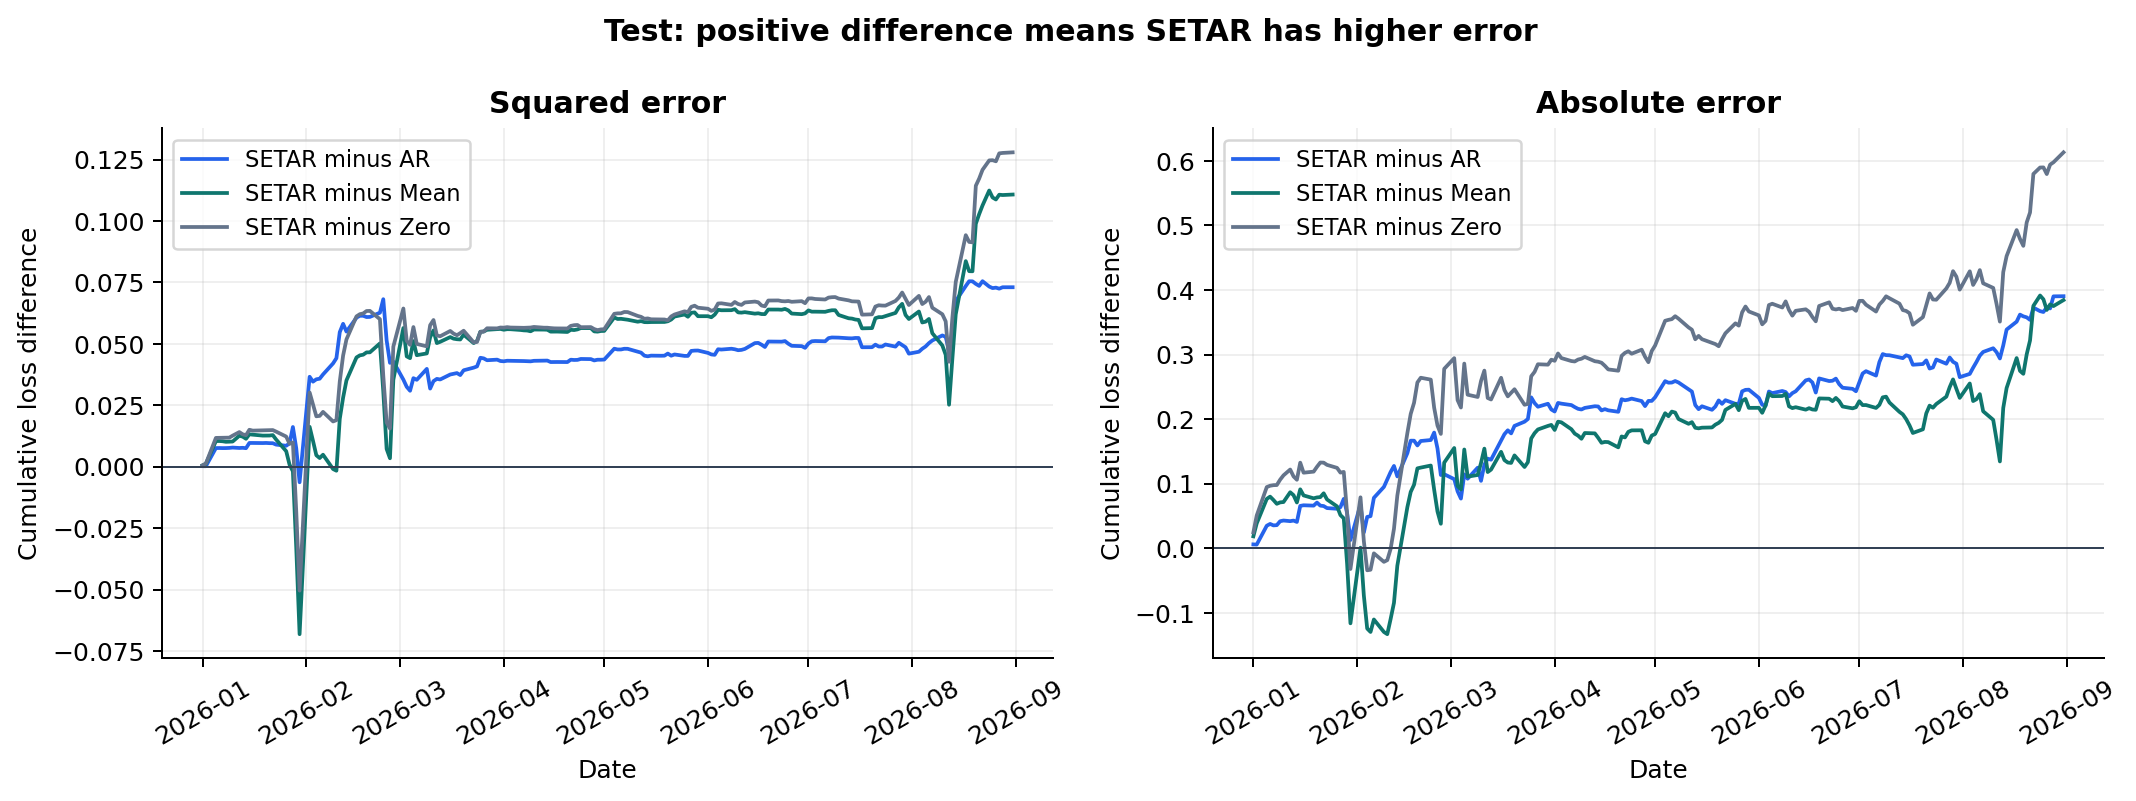

In [11]:
display(evaluation['loss_comparisons'])
display(Image(filename=str(BASE_DIR/'figures/model_4_setar_tar/06_cumulative_loss.png')))

## 13. Kết luận từ kết quả thực tế

Đọc đồng thời point forecast, benchmark, interval và diagnostics. Coverage 96% (nếu xuất hiện) là tỷ lệ giá nằm trong khoảng dự báo, **không phải accuracy dự báo hướng hoặc 96% dự báo đúng tỷ giá**. Không chỉnh mô hình dựa trên Test.

In [12]:
display(Markdown((BASE_DIR/'results/model_4_setar_tar/README.md').read_text(encoding='utf-8')))

# Mô hình 4 — SETAR/TAR cho tỷ giá USD/VND

SETAR là TAR tự kích hoạt: ngưỡng được xác định bởi return quá khứ của chính chuỗi, không phải biến ngoại sinh.

## Mô hình và giao thức

r_t = 100 log(P_t / P_(t-1)). Nếu r_(t-d) <= gamma, dùng AR(p) của chế độ Low; ngược lại dùng AR(p) của chế độ High. Mỗi chế độ có intercept và hệ số riêng.

- Train 2016–2024: fit bằng bình phương tối thiểu có điều kiện; tìm gamma bằng SSR nhỏ nhất.
- Thử p=1..10, d=1..5; gamma tại tối đa 71 phân vị trong khoảng 15%–85%; mỗi chế độ cần ít nhất 15% số quan sát và 5(p+1) quan sát.
- Chọn p,d bằng RMSE return trên Validation 2025; hòa điểm thì ưu tiên p,d nhỏ hơn. AIC/BIC không dùng để chọn trên Test.
- Refit hệ số và gamma trên Train+Validation, giữ p,d đã chọn. Tất cả cấu hình cố định trước khi đánh giá Test.
- Test 01/01–31/08/2026: 175 dự báo rolling one-step. Chỉ cập nhật lag bằng quan sát đã xảy ra, không fit lại tham số.
- Low/High nói về biến ngưỡng quá khứ, không phải khẳng định phiên kế tiếp giảm/tăng.

Cấu hình chọn bằng Validation, ngưỡng fit trên Train: p=6, d=4, gamma=-0.03939218 điểm phần trăm.
Mô hình cuối: p=6, d=4, gamma=-0.03880847; Low=624, High=1974 quan sát fit.

## Đánh giá return

| Split      | Model   |   N |      MAE |     RMSE |     MASE |   R2_out_of_sample |   DA_all_percent |   DA_nonzero_actual_percent |   Relative_RMSE_vs_Naive |
|:-----------|:--------|----:|---------:|---------:|---------:|-------------------:|-----------------:|----------------------------:|-------------------------:|
| validation | Zero    | 262 | 0.097492 | 0.168590 | 0.915013 |          -0.005169 |         8.396947 |                    0.000000 |                 1.000000 |
| validation | Mean    | 262 | 0.097876 | 0.168287 | 0.918620 |          -0.001561 |        47.328244 |                   51.666667 |                 0.998204 |
| validation | AR      | 262 | 0.100433 | 0.167174 | 0.942614 |           0.011655 |        42.366412 |                   46.250000 |                 0.991596 |
| validation | SETAR   | 262 | 0.100953 | 0.165605 | 0.947493 |           0.030115 |        43.893130 |                   47.916667 |                 0.982292 |
| test       | Zero    | 175 | 0.070908 | 0.115090 | 0.642222 |          -0.001864 |        10.285714 |                    0.000000 |                 1.000000 |
| test       | Mean    | 175 | 0.072214 | 0.115516 | 0.654058 |          -0.009282 |        40.000000 |                   44.585987 |                 1.003695 |
| test       | AR      | 175 | 0.072180 | 0.116444 | 0.653748 |          -0.025580 |        49.714286 |                   55.414013 |                 1.011767 |
| test       | SETAR   | 175 | 0.074411 | 0.118224 | 0.673957 |          -0.057158 |        48.571429 |                   54.140127 |                 1.027225 |

Return MAE/RMSE có đơn vị điểm phần trăm. Relative RMSE so với Zero return. MASE return dùng sai số persistence return trong mẫu huấn luyện, nên MASE<1 không đồng nghĩa thắng Zero trên Test.
MAPE/sMAPE return để trống vì target có 0, gần 0 và giá trị âm; không thay 0 bằng epsilon để tạo chỉ số đẹp.

## Đánh giá tỷ giá

Dự báo giá chính = P_(t-1) exp(r_hat/100) × mean(exp(residual/100)) của chế độ tương ứng. Hệ số smearing chỉ dùng residual của mẫu fit, nhằm hiệu chỉnh phép đổi thang phi tuyến. Forecast plug-in chưa hiệu chỉnh vẫn được lưu riêng trong forecasts.csv.

| Split      | Model   |       MAE |      RMSE |   MAPE_percent |   sMAPE_percent |     MASE |   DA_all_percent |   Relative_RMSE_vs_Naive |
|:-----------|:--------|----------:|----------:|---------------:|----------------:|---------:|-----------------:|-------------------------:|
| validation | Zero    | 25.187023 | 43.252829 |       0.097463 |        0.097492 | 1.439890 |         8.396947 |                 1.000000 |
| validation | Mean    | 25.289077 | 43.174200 |       0.097861 |        0.097884 | 1.445724 |        47.328244 |                 0.998182 |
| validation | AR      | 25.941585 | 42.895409 |       0.100420 |        0.100433 | 1.483027 |        42.748092 |                 0.991736 |
| validation | SETAR   | 26.071270 | 42.473124 |       0.100942 |        0.100956 | 1.490440 |        43.893130 |                 0.981973 |
| test       | Zero    | 18.562857 | 30.053405 |       0.070899 |        0.070908 | 1.016289 |        10.285714 |                 1.000000 |
| test       | Mean    | 18.911548 | 30.168630 |       0.072234 |        0.072238 | 1.035379 |        40.000000 |                 1.003834 |
| test       | AR      | 18.898896 | 30.406055 |       0.072188 |        0.072196 | 1.034686 |        49.714286 |                 1.011734 |
| test       | SETAR   | 19.483811 | 30.868815 |       0.074419 |        0.074430 | 1.066710 |        48.571429 |                 1.027132 |

RMSE SETAR cải thiện so với Naive trên Test: -2.7132% (âm nghĩa là kém hơn). Đây là kết quả ngoài mẫu của cấu hình đã chọn, không tiếp tục chỉnh theo Test.
MASE giá dùng mean(|P_t−P_(t-1)|) trên toàn bộ mẫu giá fit; Relative RMSE dùng Naive trên đúng Test. Hai chuẩn so sánh khác nhau.
Đối chứng gồm Zero/Naive, Mean và AR tuyến tính, đều thuộc giao thức đánh giá của thí nghiệm SETAR/TAR.

## Khoảng dự báo 95%

| Split      | Model   | Scale             |   Nominal_coverage_percent |   PI_coverage_percent |   Average_PI_width |   Mean_interval_score |   Below_lower_N |   Above_upper_N |
|:-----------|:--------|:------------------|---------------------------:|----------------------:|-------------------:|----------------------:|----------------:|----------------:|
| validation | SETAR   | return_percent    |                  95.000000 |             93.129771 |           0.545206 |              1.133663 |               7 |              11 |
| validation | SETAR   | price_VND_per_USD |                  95.000000 |             93.129771 |         141.758029 |            291.973111 |               7 |              11 |
| test       | SETAR   | return_percent    |                  95.000000 |             96.000000 |           0.566168 |              0.761781 |               3 |               4 |
| test       | SETAR   | price_VND_per_USD |                  95.000000 |             96.000000 |         148.611350 |            199.629748 |               3 |               4 |

Khoảng lấy phân vị 2,5% và 97,5% của residual mẫu fit theo từng chế độ. Đánh giá coverage, độ rộng và interval score. Khoảng xấp xỉ, chưa bao gồm bất định tham số và chưa mô hình hóa ARCH; không hiệu chỉnh bằng Test.

## Chẩn đoán và độ chắc chắn

- Có Ljung–Box ở lag 5/10/20 cho residual và residual bình phương, ARCH-LM lag 10, Jarque–Bera trên mẫu fit và forecast error Test.
- P-value chẩn đoán được dùng mô tả; chưa hiệu chỉnh kiểm định nhiều lần. Không dùng F-test thông thường để kết luận có hiệu ứng ngưỡng.
- paired_loss_comparisons.csv: chênh lệch squared/absolute loss với Zero, Mean, AR; CI95% paired circular moving-block bootstrap (2.000 mẫu, block=5, seed=20261010). Dương nghĩa SETAR kém hơn; CI chứa 0 nghĩa chưa có bằng chứng rõ về chênh lệch theo cách đánh giá này.
- Có thêm thống kê HAC với bandwidth=5 và p-value chuẩn xấp xỉ, chỉ tham khảo; mô hình AR/SETAR có thể lồng nhau, kiểm định và p-value này không thay thế kiểm định phi tuyến chuyên biệt.
- Directional Accuracy gồm down/flat/up; lưu thêm accuracy chỉ trên phiên thực tế đổi giá và balanced class recall. Zero dự báo flat nên không được diễn giải là tín hiệu dự báo hướng.
- Giữ nguyên các dòng OHLC bị gắn cờ; mô hình sử dụng Close. data_audit.csv và SHA256 đầu vào nằm trong selected_models.json.

## Chạy lại

```bash
pip install -r requirements.txt
python code/run_setar_tar_usd_vnd.py
python -m unittest discover -s code -p 'test_setar_tar_usd_vnd.py'
```

Hoặc Run All trong code/08_mo_hinh_4_setar_tar_usd_vnd.ipynb. Chạy từ thư mục gốc repo hoặc thư mục code. Kết quả nằm ở results/model_4_setar_tar và figures/model_4_setar_tar.

## Tài liệu

- Cryer & Chan, Time Series Analysis: With Applications in R, 2nd ed., Springer, 2008 (mô hình ngưỡng/phi tuyến).
- Hansen (1997), Inference in TAR Models, Studies in Nonlinear Dynamics and Econometrics, 2(1). https://users.ssc.wisc.edu/~behansen/papers/snde_97.html (phân phối suy luận ngưỡng không chuẩn).


## 14. File đầu ra và tái lập

- `results/model_4_setar_tar/`: audit, validation grid, threshold profiles, coefficients, metrics return/price, predictions, intervals, diagnostics, comparisons, cấu hình và SHA256 đầu vào.
- `figures/model_4_setar_tar/`: 11 biểu đồ (giữ số thứ tự hiện có, bỏ hình số 10).
- `selected_models.json`: tham số đủ để tái tạo dự báo, lịch chia dữ liệu, seed và giao thức.
- `run_environment.json`: phiên bản Python/thư viện đã chạy.

Nguồn: Cryer & Chan (2008), *Time Series Analysis: With Applications in R*; Hansen (1997), [Inference in TAR Models](https://users.ssc.wisc.edu/~behansen/papers/snde_97.html). Suy luận ngưỡng có phân phối không chuẩn; thí nghiệm này chưa làm kiểm định hiệu ứng ngưỡng chuyên biệt.